In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "/Users/apple/AI Matics/Fibro/ROL Project/data/Order Intake.xlsx"
# sheet_name="M1"
sheet_name="M2&H2"
df = pd.read_excel(file_path, sheet_name=sheet_name)

df.head()

,OA_No,OriginalOA_Date,Item_Code,Item_Name,Type,Party_Code,Order_Qty,Item_Category_Code,Product Group Code,Product_SubGroup_Code,Lead Time,Lead Time for Stocking
0,25005497,2025-01-09,2488.13.06600.075,"GAS SPRING, HEAVY DUTY",M2,CH0087,8.0,N07,8255,M2-825511F,35,42
1,25005515,2025-01-09,2490.14.07500.010,COMPACT GAS SPRING,M2,CI0093,1.0,N07,8255,M2-825520G,35,42
2,25005515,2025-01-09,2490.14.07500.010,COMPACT GAS SPRING,M2,CI0093,1.0,N07,8255,M2-825520G,35,42
3,25005548,2025-01-13,2487.12.06600.019,"GAS SPRING, POWER LINE",M2,CI016,2.0,N07,8255,M2-825540J,35,42
4,25005860,2025-01-28,2488.13.06600.250,"GAS SPRING, HEAVY DUTY",M2,CM090,5.0,N07,8255,M2-825511F,35,42


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36961 entries, 0 to 36960
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   OA_No                   36961 non-null  int64         
 1   OriginalOA_Date         36961 non-null  datetime64[ns]
 2   Item_Code               36961 non-null  object        
 3   Item_Name               36961 non-null  object        
 4   Type                    36961 non-null  object        
 5   Party_Code              36961 non-null  object        
 6   Order_Qty               36961 non-null  float64       
 7   Item_Category_Code      36961 non-null  object        
 8   Product Group Code      36953 non-null  object        
 9   Product_SubGroup_Code   36961 non-null  object        
 10  Lead Time               36961 non-null  int64         
 11  Lead Time for Stocking  36961 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), ob

In [63]:
df.describe(include='all')

,OA_No,OriginalOA_Date,Item_Code,Item_Name,Type,Party_Code,Order_Qty,Item_Category_Code,Product Group Code,Product_SubGroup_Code,Lead Time,Lead Time for Stocking
count,3.696100e+04,36961,36961,36961,36961,36961,36961.000000,36961,36953,36961,36961.000000,36961.000000
unique,NaN,NaN,3504,466,2,669,NaN,23,68,241,NaN,NaN
top,NaN,NaN,4960.85.100.100,"GAS SPRING, POWER LINE",M2,CM011,NaN,N07,8255,M2-827226,NaN,NaN
freq,NaN,NaN,663,7812,36920,3232,NaN,15394,10551,6068,NaN,NaN
mean,2.532642e+07,2025-10-14 23:54:04.684938240,NaN,NaN,NaN,NaN,23.981306,NaN,NaN,NaN,25.032358,32.032358
min,2.500539e+07,2025-01-01 00:00:00,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,12.000000,19.000000
25%,2.500870e+07,2025-06-26 00:00:00,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,21.000000,28.000000
50%,2.501113e+07,2025-10-15 00:00:00,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,28.000000,35.000000
75%,2.501378e+07,2026-02-04 00:00:00,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,NaN,28.000000,35.000000
max,2.700195e+07,2026-06-30 00:00:00,NaN,NaN,NaN,NaN,5000.000000,NaN,NaN,NaN,35.000000,42.000000


In [64]:
df.isnull().sum()

OA_No                     0
OriginalOA_Date           0
Item_Code                 0
Item_Name                 0
Type                      0
Party_Code                0
Order_Qty                 0
Item_Category_Code        0
Product Group Code        8
Product_SubGroup_Code     0
Lead Time                 0
Lead Time for Stocking    0
dtype: int64

In [65]:
df["OriginalOA_Date"] = pd.to_datetime(df["OriginalOA_Date"])

In [66]:
# Group all order records by Item_Code
# This creates one summary row for each product



product_summary = (
    df.groupby("Item_Code")
      .agg(
          # Take the first product name since it is the same for a given Item_Code
          Item_Name=("Item_Name", "first"),

          # Count how many orders this product has received
          Total_Orders=("OA_No", "count"),

          # Calculate the total quantity ordered for this product
          Total_Qty=("Order_Qty", "sum"),

          # Calculate the average quantity per order
          Avg_Order_Qty=("Order_Qty", "mean"),

          # Count the number of unique customers who ordered this product
          Customers=("Party_Code", "nunique"),

          # Find the first time this product was ordered
          First_Order=("OriginalOA_Date", "min"),

          # Find the latest time this product was ordered
          Last_Order=("OriginalOA_Date", "max")
      )
      .reset_index()
)

# Display the first few products
product_summary.head()

# Before running this code, df contained one row per order transaction.
# After running it, product_summary contains one row per product.

,Item_Code,Item_Name,Total_Orders,Total_Qty,Avg_Order_Qty,Customers,First_Order,Last_Order
0,011433-011.00,ASM-Tip 8OMT-S,1,10.0,10.000000,1,2026-04-06,2026-04-06
1,1028343-002,PRESSURE REGULATOR,1,1.0,1.000000,1,2025-02-10,2025-02-10
2,1028343-003,PRESSURE REGULATOR,7,10.0,1.428571,1,2026-02-10,2026-06-16
3,1028607,CARRY CASE,1,1.0,1.000000,1,2025-02-10,2025-02-10
4,1029335,CONTROL ARMATURE,1,1.0,1.000000,1,2025-02-10,2025-02-10


In [67]:
# Calculate the number of days between the first and last order
# Adding 1 ensures that products ordered on the same day have a span of 1 day instead of 0.

product_summary["Order_Span_Days"] = (
    product_summary["Last_Order"] -
    product_summary["First_Order"]
).dt.days + 1

# Display the first few rows
product_summary[[
    "Item_Code",
    "First_Order",
    "Last_Order",
    "Order_Span_Days"
]].head()

# Two products may both have 10 orders, but their ordering behavior can be very different.

,Item_Code,First_Order,Last_Order,Order_Span_Days
0,011433-011.00,2026-04-06,2026-04-06,1
1,1028343-002,2025-02-10,2025-02-10,1
2,1028343-003,2026-02-10,2026-06-16,127
3,1028607,2025-02-10,2025-02-10,1
4,1029335,2025-02-10,2025-02-10,1


In [68]:
# Calculate the average number of orders received per month
# This normalizes the order frequency based on the product's active period.

product_summary["Orders_per_Month"] = (
    product_summary["Total_Orders"] /
    (product_summary["Order_Span_Days"] / 30)
)

# Display the results
product_summary[[
    "Item_Code",
    "Total_Orders",
    "Order_Span_Days",
    "Orders_per_Month"
]].head()
2/(1/30)

#Orders per Month = [Total Orders / (Order Span in Days / 30)]

60.0

several products have First_Order and Last_Order on the same date. This means Orders_per_Month will become very large for those products and may not be a reliable feature by itself. Before using it for segmentation, we should examine the date range of your entire dataset and decide whether a different measure of ordering frequency would be more appropriate.

At this point, we have learned about each product’s overall ordering behavior. The next step is to understand how the demand changes over time.

Instead of looking at individual orders, we aggregate orders week by week. This is important because inventory decisions (such as ROL) are based on demand over time rather than individual transactions.

In [69]:
# Extract Year and Week from the order date
# This helps us aggregate orders on a weekly basis.

df["Year"] = df["OriginalOA_Date"].dt.year
df["Week"] = df["OriginalOA_Date"].dt.isocalendar().week

# Calculate weekly demand for each product
# Weekly_Order_Count : Number of order records in that week
# Weekly_Qty         : Total quantity ordered in that week

weekly_demand = (
    df.groupby(["Item_Code", "Year", "Week"])
      .agg(
          Weekly_Order_Count=("OA_No", "count"),
          Weekly_Qty=("Order_Qty", "sum")
      )
      .reset_index()
)

# Display the first few rows
weekly_demand.head()

,Item_Code,Year,Week,Weekly_Order_Count,Weekly_Qty
0,011433-011.00,2026,15,1,10.0
1,1028343-002,2025,7,1,1.0
2,1028343-003,2026,7,6,9.0
3,1028343-003,2026,25,1,1.0
4,1028607,2025,7,1,1.0


In [70]:
weekly_demand[
    weekly_demand["Item_Code"] == "10.1D300181.2"
]

,Item_Code,Year,Week,Weekly_Order_Count,Weekly_Qty


In [71]:
df[df["Item_Code"] == "10.1D300181.2"][
    ["OA_No", "OriginalOA_Date", "Order_Qty"]
]

,OA_No,OriginalOA_Date,Order_Qty


In [72]:
# Calculate weekly demand statistics for each product

weekly_stats = (
    weekly_demand.groupby("Item_Code")
    .agg(
        # Average quantity ordered per week
        Avg_Weekly_Qty=("Weekly_Qty", "mean"),

        # Variation in weekly demand
        Std_Weekly_Qty=("Weekly_Qty", "std")
    )
    .reset_index()
)

# Display the first few rows
weekly_stats.head()

,Item_Code,Avg_Weekly_Qty,Std_Weekly_Qty
0,011433-011.00,10.0,NaN
1,1028343-002,1.0,NaN
2,1028343-003,5.0,5.656854
3,1028607,1.0,NaN
4,1029335,1.0,NaN


Why is Std_Weekly_Qty NaN?

Take the first product: 03.02.25-A There is only one week’s observation.However, the standard deviation measures variation. With only one observation, there is nothing to compare against.

In [73]:
weekly_stats

,Item_Code,Avg_Weekly_Qty,Std_Weekly_Qty
0,011433-011.00,10.0,NaN
1,1028343-002,1.0,NaN
2,1028343-003,5.0,5.656854
3,1028607,1.0,NaN
4,1029335,1.0,NaN
...,...,...,...
3499,WDX14-60-0902,10.0,NaN
3500,WDX14-65-0150250-L50,4.0,NaN
3501,WDX7-70-1001-A,2.0,NaN
3502,XF 2400-50,20.0,NaN


In [74]:
# Calculate the Coefficient of Variation (CV)
# CV measures how consistent the weekly demand is.
#CV = Standard Deviation / Average Weekly Demand

weekly_stats["CV"] = (
    weekly_stats["Std_Weekly_Qty"] /
    weekly_stats["Avg_Weekly_Qty"]
)

# Display the first few rows
weekly_stats.head()

,Item_Code,Avg_Weekly_Qty,Std_Weekly_Qty,CV
0,011433-011.00,10.0,NaN,NaN
1,1028343-002,1.0,NaN,NaN
2,1028343-003,5.0,5.656854,1.131371
3,1028607,1.0,NaN,NaN
4,1029335,1.0,NaN,NaN


In [75]:
weekly_stats = weekly_stats.sort_values(by="CV", ascending=False)
weekly_stats

,Item_Code,Avg_Weekly_Qty,Std_Weekly_Qty,CV
1702,241.17.50.076,58.666667,194.106758,3.308638
2218,2480.044.03.00150,31.636364,89.059837,2.815110
2220,2480.044.03.00500,27.314286,72.050542,2.637834
1249,2361.1.0800.050,369.729730,971.567395,2.627777
1591,241.16.25.064,74.928571,196.004107,2.615879
...,...,...,...,...
3499,WDX14-60-0902,10.000000,NaN,NaN
3500,WDX14-65-0150250-L50,4.000000,NaN,NaN
3501,WDX7-70-1001-A,2.000000,NaN,NaN
3502,XF 2400-50,20.000000,NaN,NaN


Until now, the information was split across two tables:

* Overall product information (orders, quantity, customers, dates)
* Weekly demand information (average demand, variability, CV)

By merging them, we create a single feature table where each row represents one product and every column describes one aspect of its ordering behavior.

In [76]:
# Merge the weekly demand statistics with the product summary
# The merge is performed using Item_Code, which is the common key.

product_summary = product_summary.merge(
    weekly_stats,
    on="Item_Code",
    how="left"
)

# Display the first few rows
product_summary.head()

,Item_Code,Item_Name,Total_Orders,Total_Qty,Avg_Order_Qty,Customers,First_Order,Last_Order,Order_Span_Days,Orders_per_Month,Avg_Weekly_Qty,Std_Weekly_Qty,CV
0,011433-011.00,ASM-Tip 8OMT-S,1,10.0,10.000000,1,2026-04-06,2026-04-06,1,30.000000,10.0,NaN,NaN
1,1028343-002,PRESSURE REGULATOR,1,1.0,1.000000,1,2025-02-10,2025-02-10,1,30.000000,1.0,NaN,NaN
2,1028343-003,PRESSURE REGULATOR,7,10.0,1.428571,1,2026-02-10,2026-06-16,127,1.653543,5.0,5.656854,1.131371
3,1028607,CARRY CASE,1,1.0,1.000000,1,2025-02-10,2025-02-10,1,30.000000,1.0,NaN,NaN
4,1029335,CONTROL ARMATURE,1,1.0,1.000000,1,2025-02-10,2025-02-10,1,30.000000,1.0,NaN,NaN


# Exploratory Data Analysis (EDA)

The objective of this section is to understand the ordering behaviour of products by analysing their summary statistics, distributions, and demand characteristics. These insights will help identify different product categories such as Runner, Repeater, Slow Mover, and Stranger.

## 1. Product Summary Overview

In [77]:
product_summary.head()

,Item_Code,Item_Name,Total_Orders,Total_Qty,Avg_Order_Qty,Customers,First_Order,Last_Order,Order_Span_Days,Orders_per_Month,Avg_Weekly_Qty,Std_Weekly_Qty,CV
0,011433-011.00,ASM-Tip 8OMT-S,1,10.0,10.000000,1,2026-04-06,2026-04-06,1,30.000000,10.0,NaN,NaN
1,1028343-002,PRESSURE REGULATOR,1,1.0,1.000000,1,2025-02-10,2025-02-10,1,30.000000,1.0,NaN,NaN
2,1028343-003,PRESSURE REGULATOR,7,10.0,1.428571,1,2026-02-10,2026-06-16,127,1.653543,5.0,5.656854,1.131371
3,1028607,CARRY CASE,1,1.0,1.000000,1,2025-02-10,2025-02-10,1,30.000000,1.0,NaN,NaN
4,1029335,CONTROL ARMATURE,1,1.0,1.000000,1,2025-02-10,2025-02-10,1,30.000000,1.0,NaN,NaN


In [78]:
product_summary.describe()

,Total_Orders,Total_Qty,Avg_Order_Qty,Customers,First_Order,Last_Order,Order_Span_Days,Orders_per_Month,Avg_Weekly_Qty,Std_Weekly_Qty,CV
count,3504.000000,3504.000000,3504.000000,3504.000000,3504,3504,3504.000000,3504.000000,3504.000000,1905.000000,1905.000000
mean,10.548231,252.960342,28.366626,2.924372,2025-07-29 17:16:01.643835392,2026-01-09 17:52:36.164383488,165.025400,22.493596,49.142109,55.490362,0.733719
min,1.000000,1.000000,0.333333,1.000000,2025-01-01 00:00:00,2025-01-01 00:00:00,1.000000,0.118812,1.000000,0.000000,0.000000
25%,1.000000,6.000000,3.000000,1.000000,2025-02-24 00:00:00,2025-09-20 00:00:00,1.000000,0.779221,4.000000,2.828427,0.471405
50%,3.000000,20.000000,5.718254,1.000000,2025-06-23 00:00:00,2026-03-07 00:00:00,35.000000,6.000000,8.000000,7.812028,0.707107
75%,7.000000,91.250000,14.666667,2.000000,2025-12-11 00:00:00,2026-05-30 00:00:00,356.000000,30.000000,21.154937,24.095050,0.975795
max,663.000000,30625.000000,3350.000000,58.000000,2026-06-30 00:00:00,2026-06-30 00:00:00,545.000000,480.000000,10050.000000,9925.094458,3.308638
std,34.427838,1325.710223,115.302933,4.922956,NaN,NaN,196.087166,32.445293,269.594992,307.645154,0.435110


In [79]:
product_summary.isnull().sum()

Item_Code              0
Item_Name              0
Total_Orders           0
Total_Qty              0
Avg_Order_Qty          0
Customers              0
First_Order            0
Last_Order             0
Order_Span_Days        0
Orders_per_Month       0
Avg_Weekly_Qty         0
Std_Weekly_Qty      1599
CV                  1599
dtype: int64

## 2. Product Order Behaviour

Analyse how frequently products are ordered and how order quantities vary across the product portfolio.

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a consistent style for all plots
sns.set_theme(style="whitegrid", palette="Set2")
sns.set_theme(
    style="whitegrid",
    context="talk",
    palette="deep"
)

plt.rcParams["figure.dpi"] = 120

### 2.1 Distribution of Total Orders

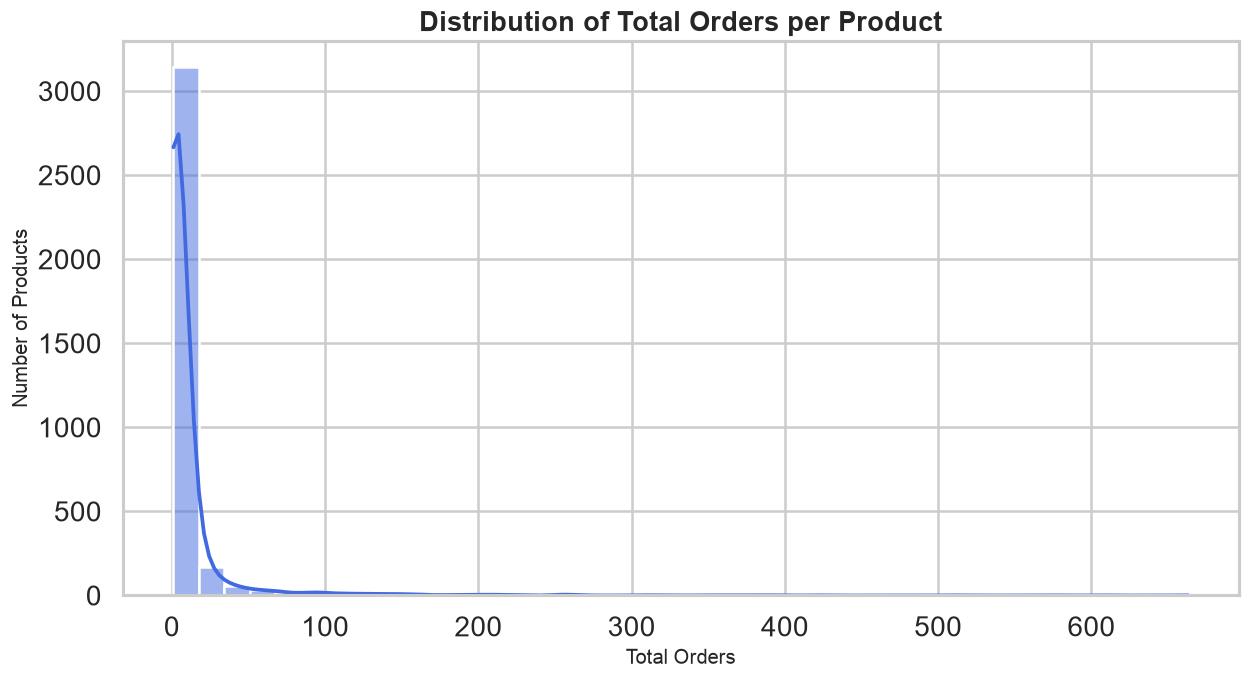

In [81]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=product_summary,
    x="Total_Orders",
    bins=40,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Total Orders per Product", fontsize=16, weight="bold")
plt.xlabel("Total Orders", fontsize=12)
plt.ylabel("Number of Products", fontsize=12)

plt.show()

### 2.2 Distribution of Total Quantity Ordered

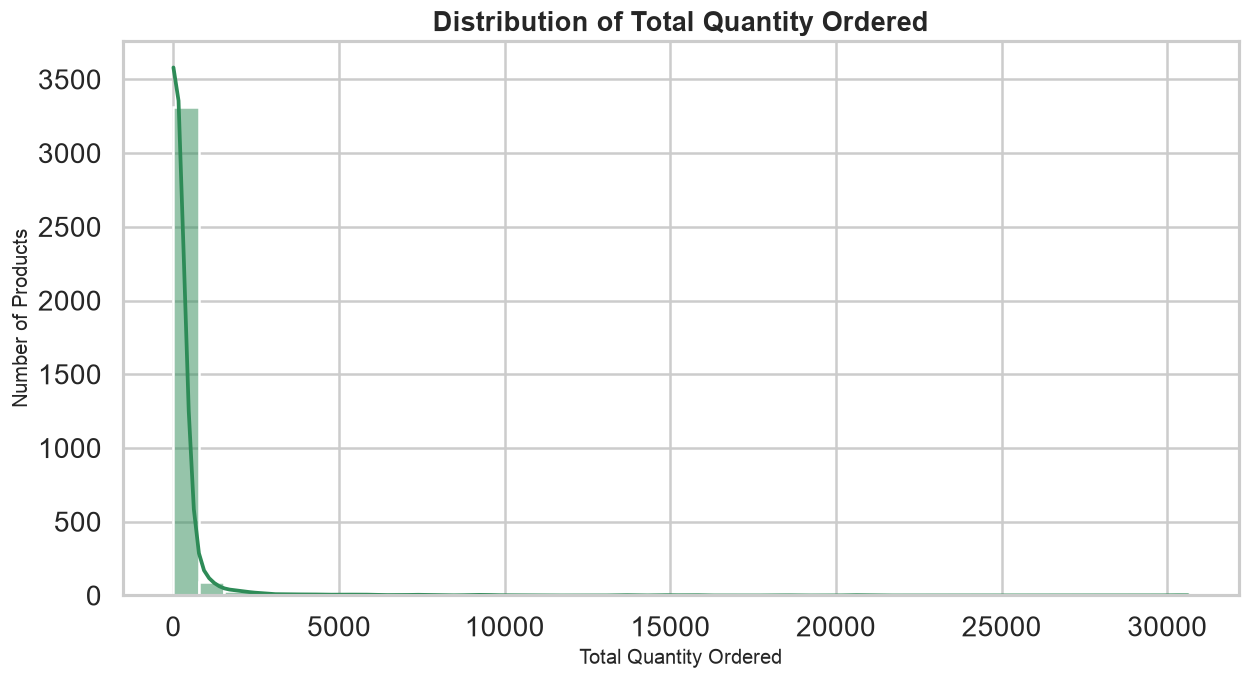

In [82]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=product_summary,
    x="Total_Qty",
    bins=40,
    kde=True,
    color="seagreen"
)

plt.title("Distribution of Total Quantity Ordered", fontsize=16, weight="bold")
plt.xlabel("Total Quantity Ordered", fontsize=12)
plt.ylabel("Number of Products", fontsize=12)

plt.show()

### 2.3 Top 20 Products by Number of Orders

/var/folders/6z/z51dtvmj6pz5k2yqlwmqdmx80000gn/T/ipykernel_34869/3202531618.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


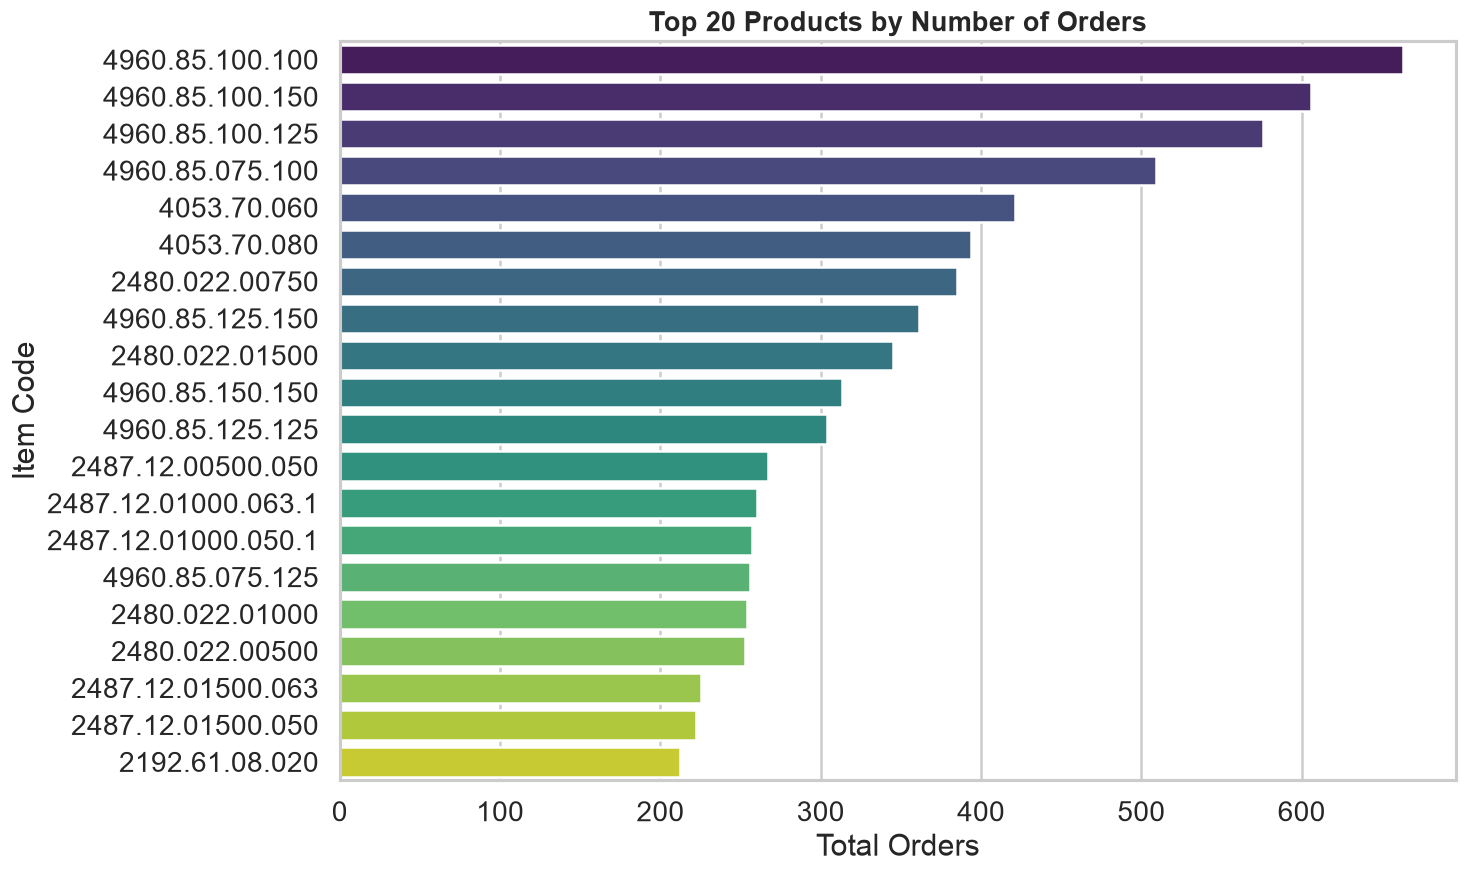

In [83]:
top_orders = (
    product_summary
    .sort_values("Total_Orders", ascending=False)
    .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_orders,
    y="Item_Code",
    x="Total_Orders",
    palette="viridis"
)

plt.title("Top 20 Products by Number of Orders", fontsize=16, weight="bold")
plt.xlabel("Total Orders")
plt.ylabel("Item Code")

plt.show()

### 2.4 Top 20 Products by Total Quantity

/var/folders/6z/z51dtvmj6pz5k2yqlwmqdmx80000gn/T/ipykernel_34869/2705601086.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


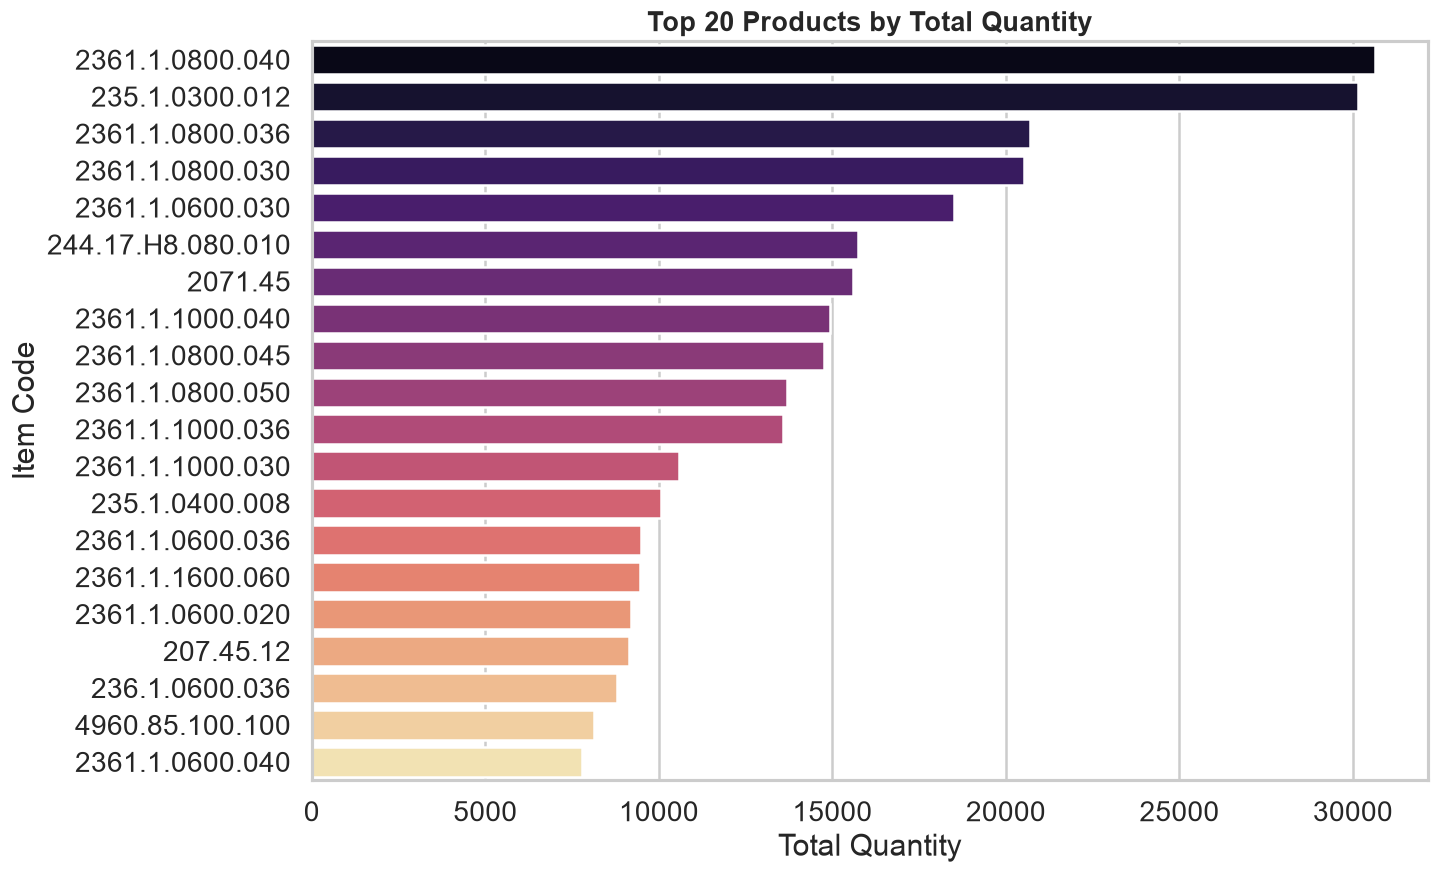

In [84]:
top_qty = (
    product_summary
    .sort_values("Total_Qty", ascending=False)
    .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_qty,
    y="Item_Code",
    x="Total_Qty",
    palette="magma"
)

plt.title("Top 20 Products by Total Quantity", fontsize=16, weight="bold")
plt.xlabel("Total Quantity")
plt.ylabel("Item Code")

plt.show()

### 2.5 Relationship between Total Orders and Total Quantity

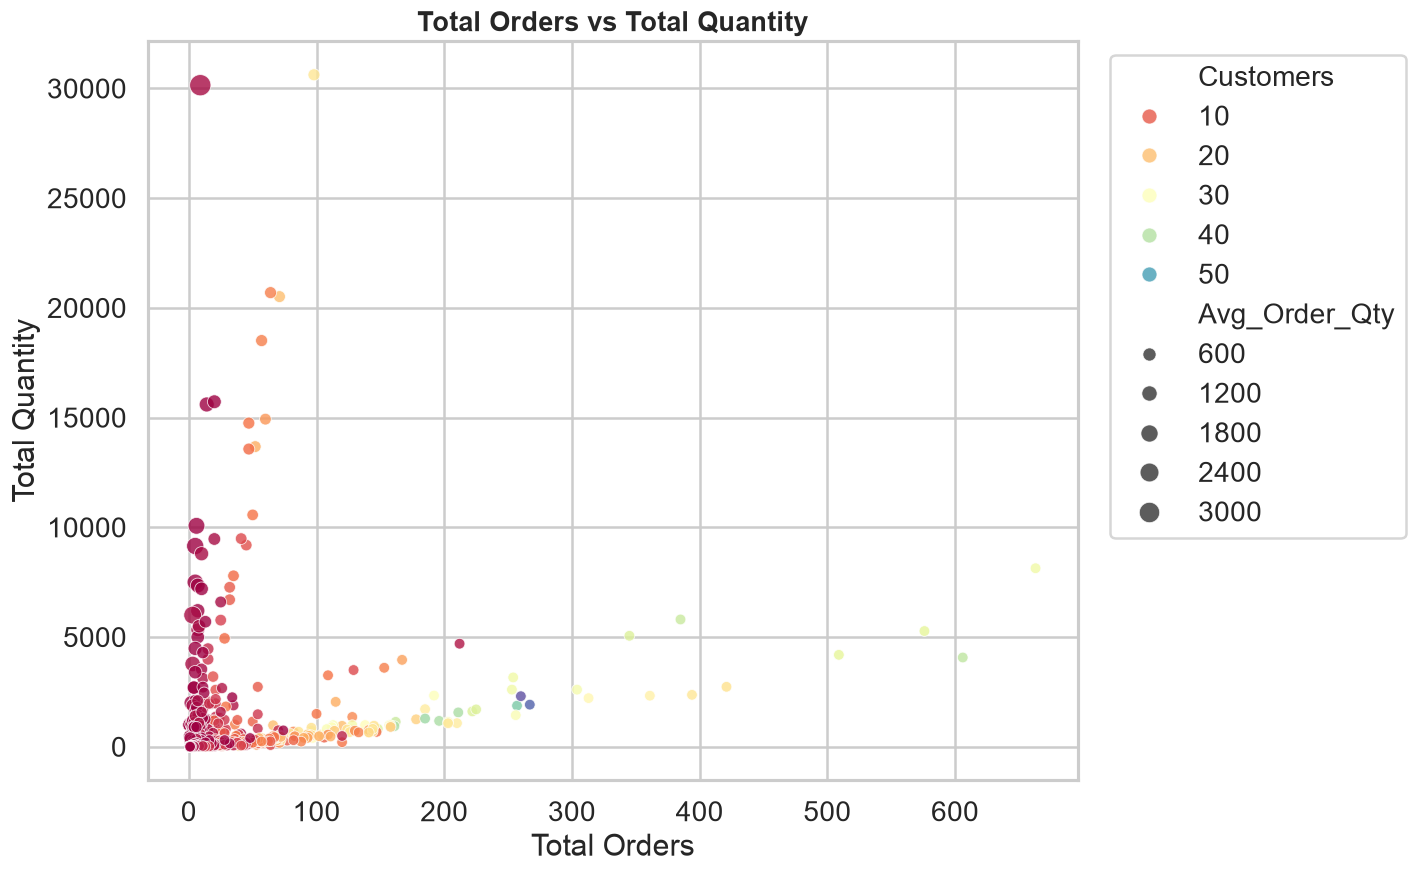

In [85]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=product_summary,
    x="Total_Orders",
    y="Total_Qty",
    hue="Customers",
    size="Avg_Order_Qty",
    palette="Spectral",
    alpha=0.8
)

plt.title("Total Orders vs Total Quantity", fontsize=16, weight="bold")
plt.xlabel("Total Orders")
plt.ylabel("Total Quantity")

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.show()

### Observation

- The majority of products are concentrated in the lower-left region of the plot, indicating that most products receive relatively few orders and contribute a low total order quantity.

- A small number of products exhibit exceptionally high total quantities, making them clear outliers. These products are likely responsible for a significant share of the overall demand.

- A positive relationship exists between **Total Orders** and **Total Quantity**, suggesting that products ordered more frequently generally contribute higher cumulative demand. However, the relationship is not strictly linear due to variations in order size.

- Several products have a high number of orders but moderate total quantities, indicating frequent purchases in smaller batches. Conversely, some products have very few orders but extremely high total quantities, suggesting bulk or project-based ordering.

- The colour gradient indicates that most products are purchased by a limited number of customers, while only a few products have a broad customer base.

- The marker size shows that average order quantity varies considerably across products. Some products with low order frequency have large average order quantities, whereas frequently ordered products often have smaller average order sizes.

- The presence of a few extreme outliers compresses the majority of observations into a dense cluster near the origin, making subtle behavioural differences difficult to distinguish. Applying a logarithmic scale or excluding extreme outliers in a separate visualization would provide a clearer view of the overall product distribution.

### 2.6 Distribution and Outliers in Product Orders

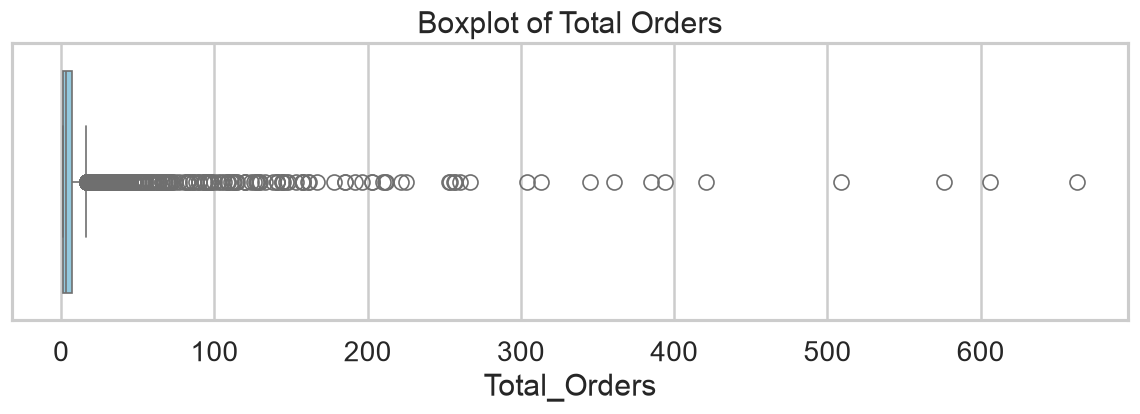

In [86]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=product_summary["Total_Orders"],
    color="skyblue"
)

plt.title("Boxplot of Total Orders")

plt.show()

### Observation

- The boxplot of **Total Orders** indicates that the majority of products receive a relatively small number of orders, with the median and interquartile range concentrated near the lower end of the distribution.

- A large number of observations lie beyond the upper whisker, indicating the presence of many high-order outliers. These products are ordered significantly more frequently than the typical product.

- The maximum number of orders exceeds **350**, demonstrating that a small subset of products accounts for a disproportionately high ordering frequency.

- The distribution is highly right-skewed, suggesting that while most products are ordered infrequently, a limited number of products exhibit consistently high demand.

### 2.7 Distribution and Outliers in Product Quantity

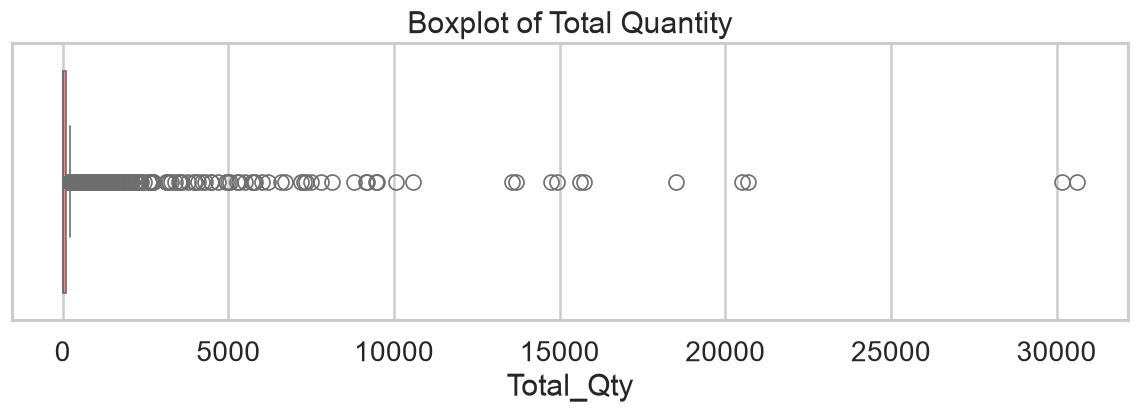

In [87]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=product_summary["Total_Qty"],
    color="lightcoral"
)

plt.title("Boxplot of Total Quantity")

plt.show()

### Observation

- Similarly, the **Total Quantity** boxplot reveals that most products contribute relatively low order quantities, whereas a few products have exceptionally large cumulative quantities.

- Several extreme quantity outliers, exceeding **40,000 units**, indicate products with substantially higher demand than the rest of the portfolio.

- The presence of numerous outliers in both order frequency and total quantity suggests that the product portfolio is heterogeneous, consisting of both low-demand products and a small number of dominant high-demand products.

- Since these extreme observations compress the majority of products into a narrow range, robust statistical measures such as the median and interquartile range are more representative than the mean for describing the overall distribution.

# 3. ABC Analysis

ABC analysis is an inventory classification technique based on the Pareto principle, which states that a small proportion of products typically contributes to a large proportion of the overall demand. The objective of this analysis is to classify products into A, B, and C categories based on their contribution to the total ordered quantity.

Products in Category A represent the most significant contributors to total demand and require close inventory monitoring. Category B products have moderate demand contribution, while Category C products contribute the least and generally require less inventory control.

### 3.1 Product Contribution Analysis

In [88]:
# Sort products by total ordered quantity in descending order

abc_df = (
    product_summary
    .sort_values("Total_Qty", ascending=False)
    .copy()
)

# Calculate total quantity ordered across all products

total_qty = abc_df["Total_Qty"].sum()

# Calculate percentage contribution of each product

abc_df["Contribution (%)"] = (
    abc_df["Total_Qty"] / total_qty
) * 100

# Calculate cumulative contribution

abc_df["Cumulative Contribution (%)"] = (
    abc_df["Contribution (%)"].cumsum()
)

abc_df.head()

,Item_Code,Item_Name,Total_Orders,Total_Qty,Avg_Order_Qty,Customers,First_Order,Last_Order,Order_Span_Days,Orders_per_Month,Avg_Weekly_Qty,Std_Weekly_Qty,CV,Contribution (%),Cumulative Contribution (%)
1247,2361.1.0800.040,DOWEL PINS ZI,98,30625.0,312.500000,25,2025-01-04,2026-06-29,542,5.424354,651.595745,1146.043509,1.758826,3.455092,3.455092
1023,235.1.0300.012,"DOWEL PIN SIMILAR TO DIN EN ISO 8734, M5 TOLER...",9,30150.0,3350.000000,2,2025-04-25,2026-01-20,271,0.996310,10050.000000,9925.094458,0.987572,3.401502,6.856594
1246,2361.1.0800.036,DOWEL PINS ZI,64,20697.0,323.390625,14,2025-02-17,2026-06-27,496,3.870968,689.900000,988.277231,1.432493,2.335021,9.191615
1244,2361.1.0800.030,DOWEL PINS ZI,71,20516.0,288.957746,20,2025-01-06,2026-06-27,538,3.959108,621.696970,1205.413764,1.938909,2.314601,11.506216
1229,2361.1.0600.030,DOWEL PINS ZI,57,18512.0,324.771930,14,2025-02-09,2026-06-29,506,3.379447,514.222222,1083.863621,2.107773,2.088511,13.594728


### 3.2 Product Classification using ABC Analysis

In [89]:
# Assign ABC category based on cumulative contribution

def classify_abc(cum_pct):
    if cum_pct <= 80:
        return "A"
    elif cum_pct <= 95:
        return "B"
    else:
        return "C"

abc_df["ABC_Class"] = (
    abc_df["Cumulative Contribution (%)"]
    .apply(classify_abc)
)

abc_df.head()

,Item_Code,Item_Name,Total_Orders,Total_Qty,Avg_Order_Qty,Customers,First_Order,Last_Order,Order_Span_Days,Orders_per_Month,Avg_Weekly_Qty,Std_Weekly_Qty,CV,Contribution (%),Cumulative Contribution (%),ABC_Class
1247,2361.1.0800.040,DOWEL PINS ZI,98,30625.0,312.500000,25,2025-01-04,2026-06-29,542,5.424354,651.595745,1146.043509,1.758826,3.455092,3.455092,A
1023,235.1.0300.012,"DOWEL PIN SIMILAR TO DIN EN ISO 8734, M5 TOLER...",9,30150.0,3350.000000,2,2025-04-25,2026-01-20,271,0.996310,10050.000000,9925.094458,0.987572,3.401502,6.856594,A
1246,2361.1.0800.036,DOWEL PINS ZI,64,20697.0,323.390625,14,2025-02-17,2026-06-27,496,3.870968,689.900000,988.277231,1.432493,2.335021,9.191615,A
1244,2361.1.0800.030,DOWEL PINS ZI,71,20516.0,288.957746,20,2025-01-06,2026-06-27,538,3.959108,621.696970,1205.413764,1.938909,2.314601,11.506216,A
1229,2361.1.0600.030,DOWEL PINS ZI,57,18512.0,324.771930,14,2025-02-09,2026-06-29,506,3.379447,514.222222,1083.863621,2.107773,2.088511,13.594728,A


### 3.3 Distribution of ABC Categories

/var/folders/6z/z51dtvmj6pz5k2yqlwmqdmx80000gn/T/ipykernel_34869/1142087518.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


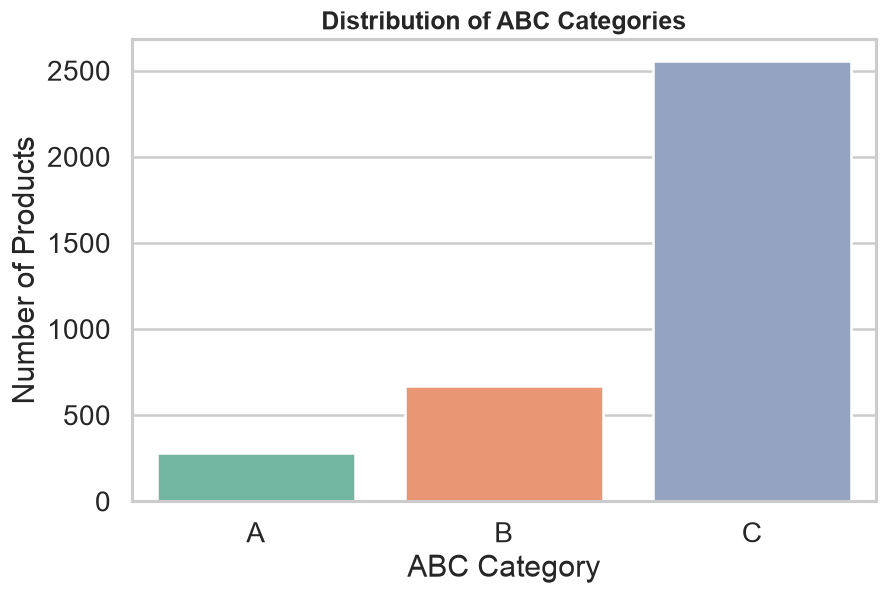

In [90]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=abc_df,
    x="ABC_Class",
    palette="Set2",
    order=["A", "B", "C"]
)

plt.title("Distribution of ABC Categories", fontsize=15, weight="bold")
plt.xlabel("ABC Category")
plt.ylabel("Number of Products")

plt.show()

### 3.4 Pareto Analysis

In [91]:
# Summary statistics for each ABC category

abc_summary = (
    abc_df.groupby("ABC_Class")
    .agg(
        Products=("Item_Code", "count"),
        Avg_Orders=("Total_Orders", "mean"),
        Avg_Qty=("Total_Qty", "mean"),
        Avg_Customers=("Customers", "mean")
    )
    .reset_index()
)

abc_summary

,ABC_Class,Products,Avg_Orders,Avg_Qty,Avg_Customers
0,A,282,62.627660,2512.787234,10.237589
1,B,668,16.269461,199.744072,4.974551
2,C,2554,3.301488,17.360219,1.580658


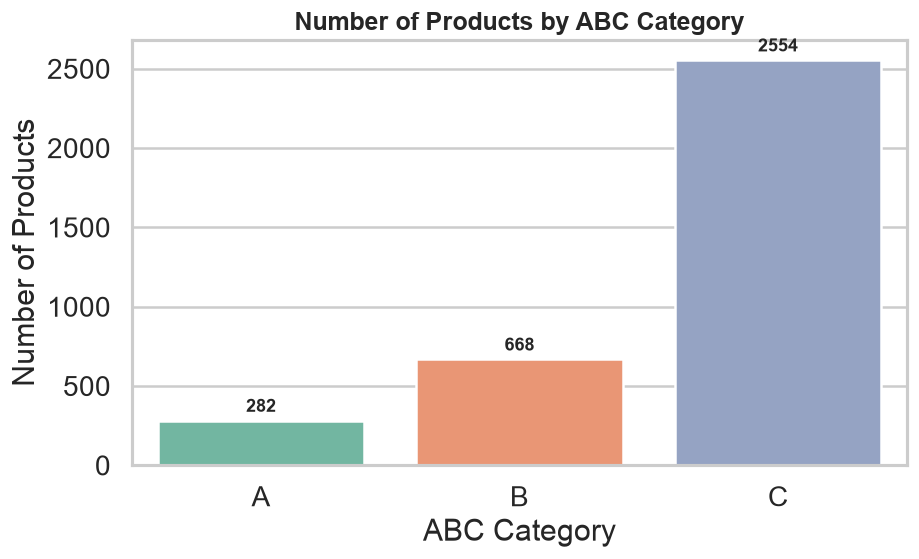

In [92]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=abc_summary,
    x="ABC_Class",
    y="Products",
    hue="ABC_Class",
    palette="Set2",
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=11, weight="bold")

plt.title("Number of Products by ABC Category", fontsize=15, weight="bold")
plt.xlabel("ABC Category")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

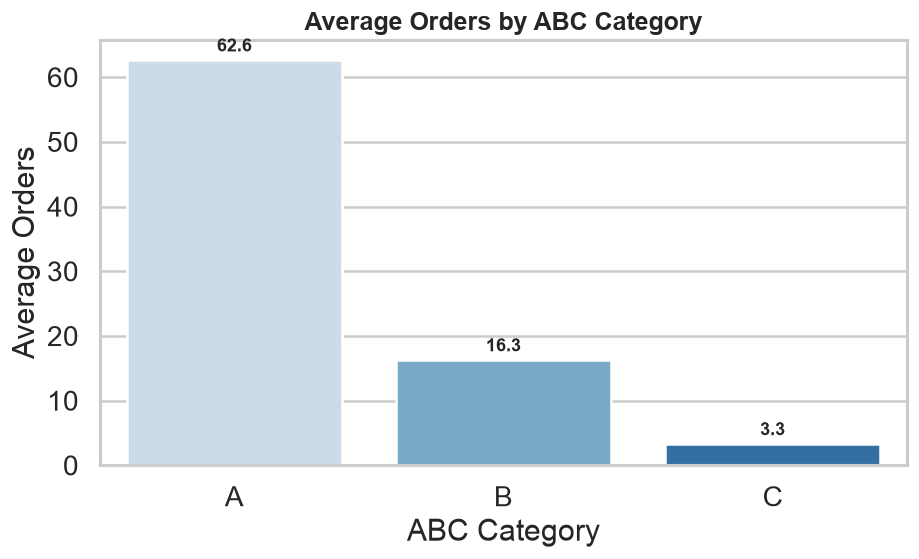

In [93]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=abc_summary,
    x="ABC_Class",
    y="Avg_Orders",
    hue="ABC_Class",
    palette="Blues",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=11, weight="bold")

plt.title("Average Orders by ABC Category", fontsize=15, weight="bold")
plt.xlabel("ABC Category")
plt.ylabel("Average Orders")

plt.tight_layout()
plt.show()

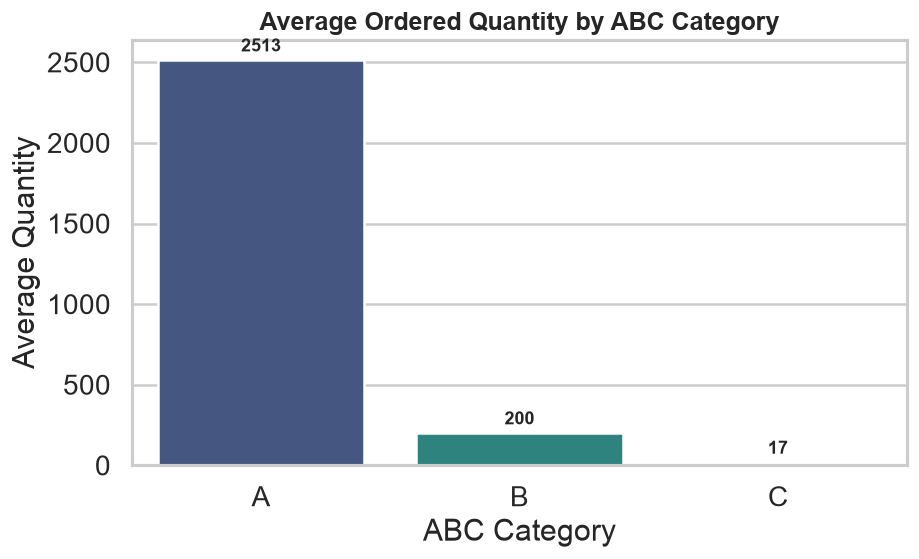

In [94]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=abc_summary,
    x="ABC_Class",
    y="Avg_Qty",
    hue="ABC_Class",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=11, weight="bold")

plt.title("Average Ordered Quantity by ABC Category", fontsize=15, weight="bold")
plt.xlabel("ABC Category")
plt.ylabel("Average Quantity")

plt.tight_layout()
plt.show()

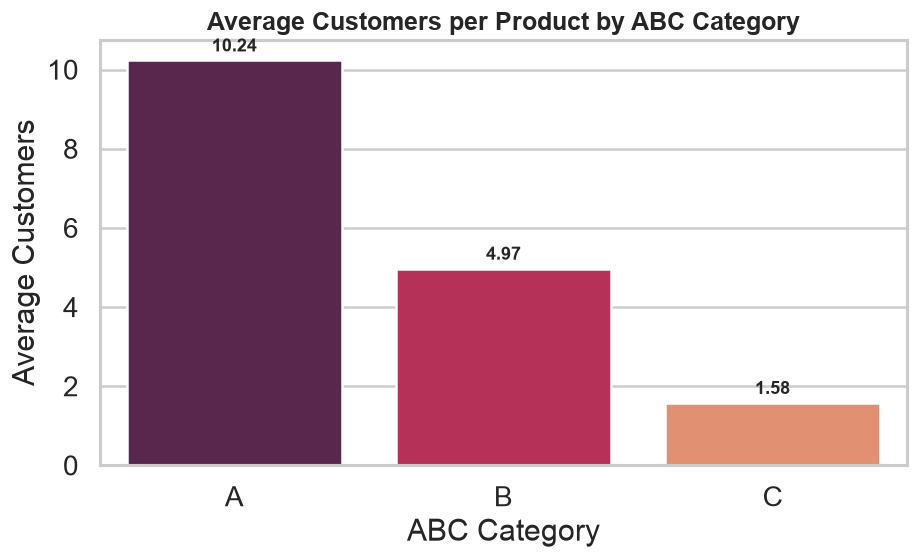

In [95]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=abc_summary,
    x="ABC_Class",
    y="Avg_Customers",
    hue="ABC_Class",
    palette="rocket",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=11, weight="bold")

plt.title("Average Customers per Product by ABC Category", fontsize=15, weight="bold")
plt.xlabel("ABC Category")
plt.ylabel("Average Customers")

plt.tight_layout()
plt.show()

### 3.5 Comparative Analysis of ABC Categories

This section compares the characteristics of products across the three ABC categories. The comparison provides insights into differences in ordering frequency, demand volume, average order size, and customer reach.

In [96]:
abc_summary = (
    abc_df.groupby("ABC_Class")
    .agg(
        Products=("Item_Code", "count"),
        Avg_Orders=("Total_Orders", "mean"),
        Avg_Qty=("Total_Qty", "mean"),
        Avg_Order_Qty=("Avg_Order_Qty", "mean"),
        Avg_Customers=("Customers", "mean")
    )
    .round(2)
)

abc_summary

,Products,Avg_Orders,Avg_Qty,Avg_Order_Qty,Avg_Customers
ABC_Class,,,,,
A,282,62.63,2512.79,204.85,10.24
B,668,16.27,199.74,35.64,4.97
C,2554,3.30,17.36,6.98,1.58


### 3.6 Key Observations

### Observation

- Category A consists of a relatively small number of products but contributes the largest share of the total ordered quantity, confirming the Pareto principle.

- Category B represents products with moderate demand contribution and ordering frequency. These products require periodic inventory monitoring.

- Category C contains the largest proportion of products but contributes only a small fraction of the total demand. These products are generally slow-moving and require minimal inventory investment.

- The average number of orders decreases from Category A to Category C, indicating that high-value products are typically ordered more frequently.

- The average ordered quantity is significantly higher for Category A products, suggesting that they have a greater impact on inventory consumption.

- The average number of customers can provide additional insight into product popularity. Products purchased by a larger customer base generally exhibit broader market demand.

- The ABC classification provides a systematic approach for prioritizing inventory management by identifying products that require different levels of monitoring and replenishment.

- The results of this analysis will serve as the foundation for the next stage, where products will be further analysed using RF Analysis to identify behavioural categories such as Runner, Repeater, Slow Mover, and Stranger.

# 4. RF Analysis

RF (Recency and Frequency) Analysis is used to evaluate the ordering behaviour of products based on how recently they were ordered and how frequently they are ordered. Unlike traditional customer RFM analysis, this study applies the RF framework to products, where each product is evaluated using its recency and ordering frequency. The objective is to identify products that are actively ordered, repeatedly ordered, or becoming inactive, which can support inventory planning and replenishment decisions.

### 4.1 Calculate Product Recency

In [97]:
# Find the latest order date in the dataset
analysis_date = df["OriginalOA_Date"].max()

# Calculate the recency of each product
product_summary["Recency"] = (
    analysis_date - product_summary["Last_Order"]
).dt.days

product_summary[
    ["Item_Code", "Last_Order", "Recency"]
].head()

,Item_Code,Last_Order,Recency
0,011433-011.00,2026-04-06,85
1,1028343-002,2025-02-10,505
2,1028343-003,2026-06-16,14
3,1028607,2025-02-10,505
4,1029335,2025-02-10,505


In [98]:
analysis_date

Timestamp('2026-06-30 00:00:00')

### 4.2 Frequency Analysis

In [99]:
product_summary[
    ["Item_Code", "Recency", "Total_Orders"]
].head()

,Item_Code,Recency,Total_Orders
0,011433-011.00,85,1
1,1028343-002,505,1
2,1028343-003,14,7
3,1028607,505,1
4,1029335,505,1


### 4.3 Distribution of Product Recency

This analysis examines how recently products have been ordered. Products with lower recency values are actively ordered, whereas products with higher recency values may indicate declining demand or inactive inventory.

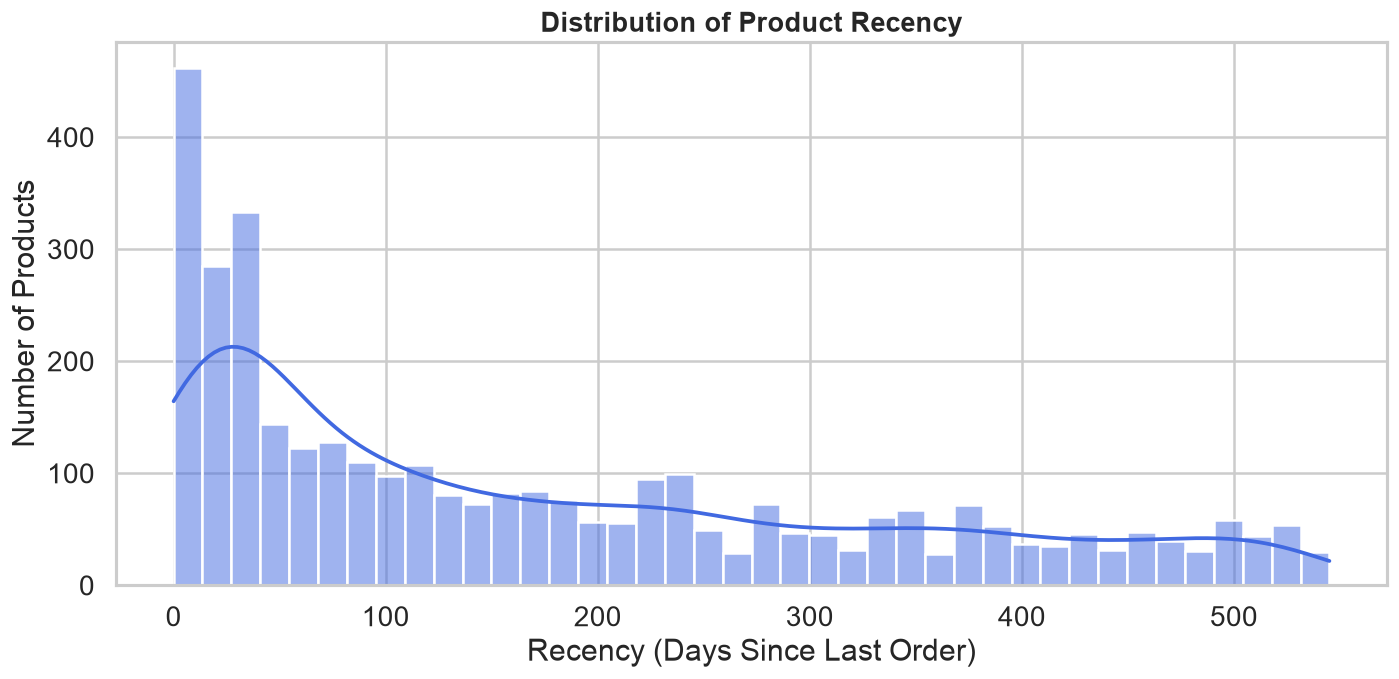

In [100]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=product_summary,
    x="Recency",
    bins=40,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Product Recency", fontsize=16, weight="bold")
plt.xlabel("Recency (Days Since Last Order)")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

### 4.4 Distribution of Product Frequency

This analysis shows how frequently products have been ordered throughout the observation period. Products with a higher number of orders are generally more active and may represent runner or repeater products.

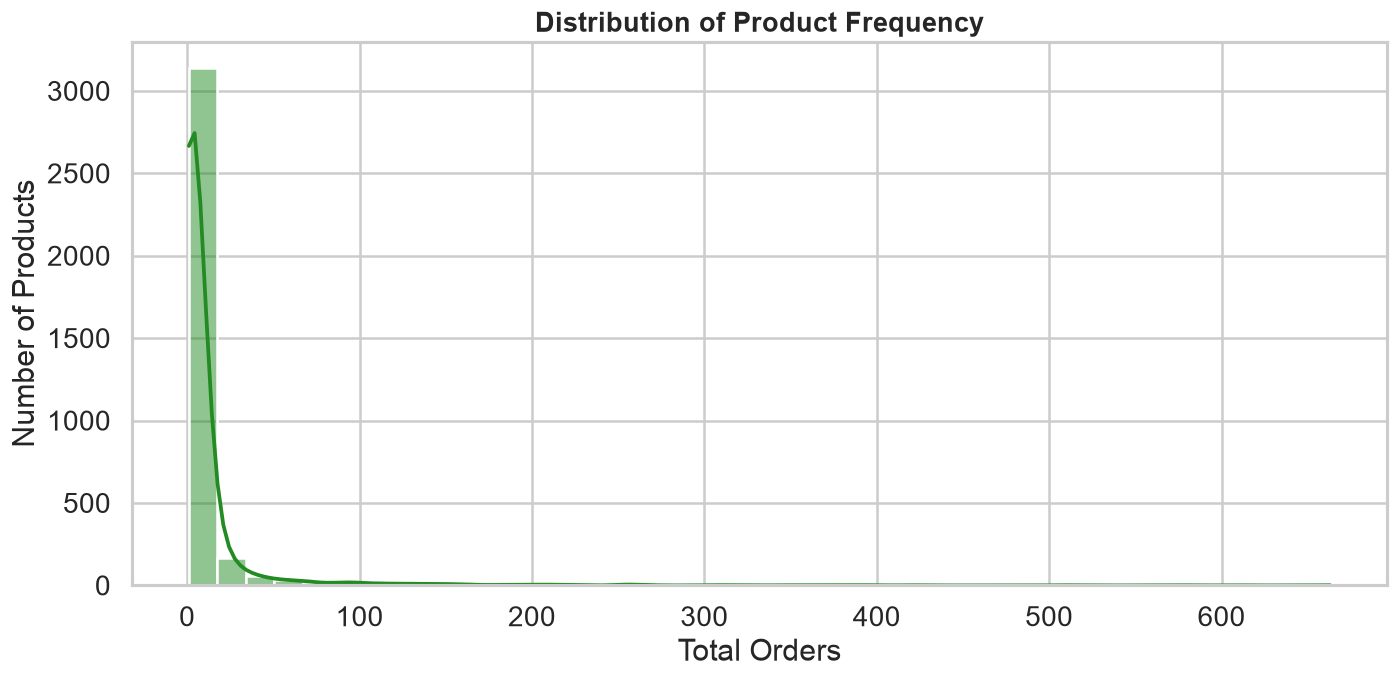

In [101]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=product_summary,
    x="Total_Orders",
    bins=40,
    kde=True,
    color="forestgreen"
)

plt.title("Distribution of Product Frequency", fontsize=16, weight="bold")
plt.xlabel("Total Orders")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

### 4.5 Relationship Between Product Recency and Frequency

This scatter plot illustrates the relationship between product recency and ordering frequency. The plot provides an initial view of product ordering behaviour before assigning RF scores. The dashed lines represent the median values of recency and frequency, dividing the products into four behavioural regions.

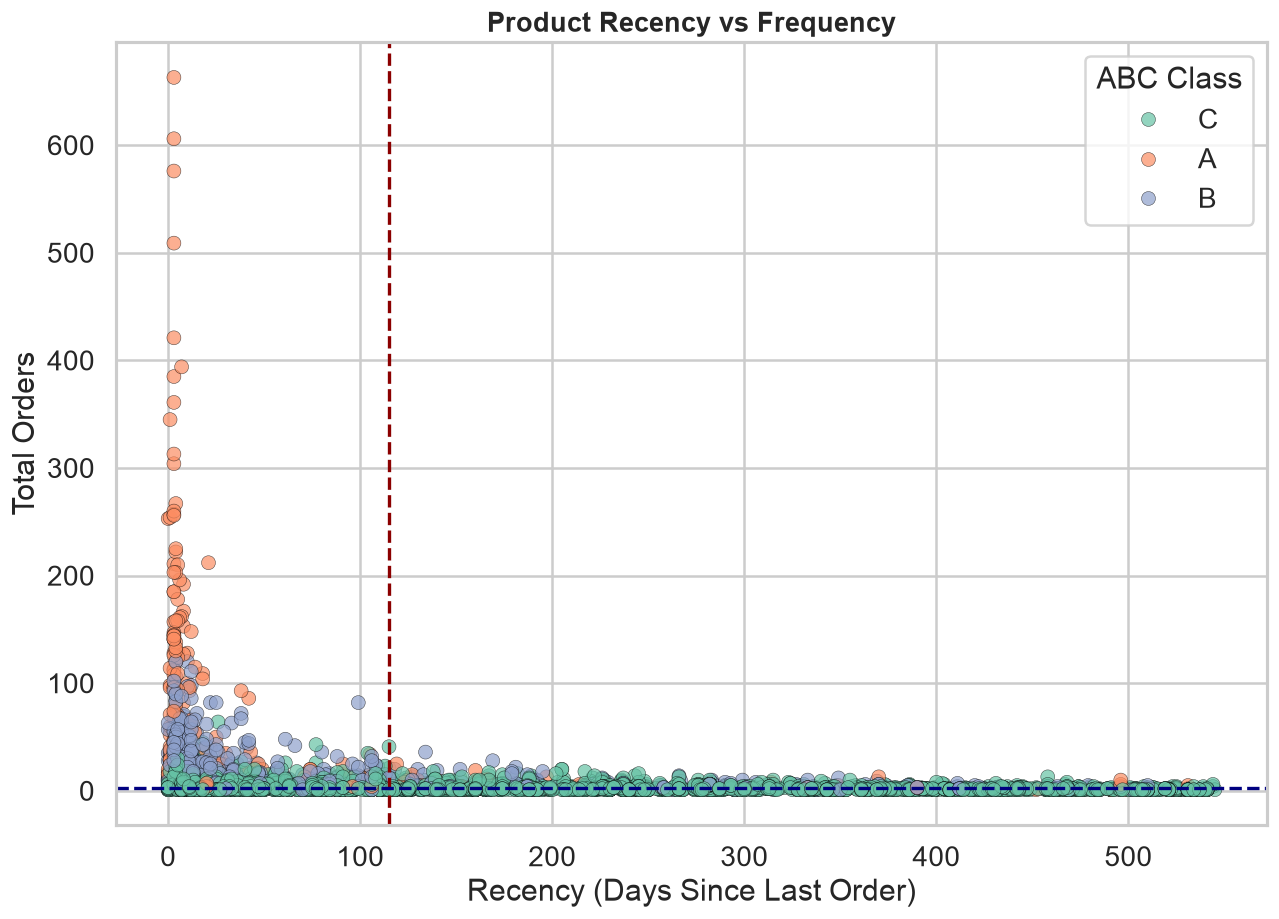

In [102]:
product_summary = product_summary.merge(
    abc_df[["Item_Code", "ABC_Class"]],
    on="Item_Code",
    how="left"
)

plt.figure(figsize=(11,8))

ax = sns.scatterplot(
    data=product_summary,
    x="Recency",
    y="Total_Orders",
    hue="ABC_Class",
    palette="Set2",
    s=70,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.3
)

# Median reference lines
plt.axvline(
    product_summary["Recency"].median(),
    color="darkred",
    linestyle="--",
    linewidth=2
)

plt.axhline(
    product_summary["Total_Orders"].median(),
    color="navy",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Product Recency vs Frequency",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Recency (Days Since Last Order)")
plt.ylabel("Total Orders")

plt.legend(title="ABC Class")

plt.tight_layout()
plt.show()

### Observation

- Products are highly concentrated in the lower-left region of the plot, indicating that most products have relatively low order frequency while also being ordered recently.

- Only a small number of products exhibit high ordering frequency, suggesting that a limited set of products accounts for repeated customer demand.

- Products with high recency and low order frequency are potential slow-moving or inactive products that may require inventory review.

- Category A products are primarily concentrated in the low-recency region, indicating that the highest-demand products continue to receive recent orders.

- Categories B and C are more widely distributed across the recency axis, suggesting greater variability in ordering behaviour.

- The scatter plot provides an initial understanding of product behaviour. Final product categories such as Runner, Repeater, Slow Mover, and Stranger will be determined using RF scores rather than visual inspection alone.

| ABC Category | Behaviour Observed | Inventory Priority | Recommended Action |
|--------------|-------------------|-------------------|--------------------|
| **A** | High frequency and recent ordering activity. Products are concentrated in the upper-left region of the plot. | **Highest** | Maintain 98-99% service level, continuous review, higher safety stock, and frequent replenishment. |
| **B** | Moderate ordering frequency with mixed recency. Products are distributed across both active and inactive regions. | **Medium** | Apply periodic inventory reviews and adjust safety stock according to the RF category. |
| **C** | Low ordering frequency and long periods since the last order. Products are concentrated in the lower-right region. | **Lowest** | Maintain lean inventory, reduce replenishment frequency, review dormant items, and consider make-to-order or product rationalization where appropriate. |

### RF Analysis

In [103]:
# Assign Recency scores using quintiles
#Lower recency means a higher score, so the labels are reversed.
product_summary["R_Score"] = pd.qcut(
    product_summary["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)


# Assign Frequency scores using quintiles
product_summary["F_Score"] = pd.qcut(
    product_summary["Total_Orders"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)


product_summary["RF_Score"] = (
    product_summary["R_Score"].astype(str)
    + product_summary["F_Score"].astype(str)
)

product_summary[
    ["Item_Code", "Recency", "Total_Orders", "R_Score", "F_Score", "RF_Score"]
].head()


,Item_Code,Recency,Total_Orders,R_Score,F_Score,RF_Score
0,011433-011.00,85,1,3,1,31
1,1028343-002,505,1,1,1,11
2,1028343-003,14,7,5,4,54
3,1028607,505,1,1,1,11
4,1029335,505,1,1,1,11


### 4.7 Product Classification Using RF Scores

Products are classified into behavioural categories based on their Recency (R) and Frequency (F) scores. The objective of this classification is to distinguish actively ordered products from infrequently ordered or inactive products, enabling differentiated inventory management strategies.

In [104]:
# Function to classify products based on RF scores

# def classify_rf(row):
#     r = row["R_Score"]
#     f = row["F_Score"]

#     if r >= 4 and f >= 4:
#         return "Runner"

#     elif r >= 4 and f >= 2:
#         return "Repeater"

#     elif r <= 2 and f <= 2:
#         return "Slow Mover"

#     else:
#         return "Stranger"

# Function to classify products based on RF scores

# Function to classify products based on RF scores

def classify_rf(row):
    r = row["R_Score"]
    f = row["F_Score"]

    # High recency and high frequency
    if r >= 4 and f >= 4:
        return "Runner"
    
    #44, 45, 54, 55

    # Moderate products with fairly recent and/or repeated demand
    elif (r >= 3 and f >= 3):
        return "Repeater"

    # Low recency and low frequency
    elif (r <= 2 and f <= 2):
        return "Dormant"

    # Remaining products
    else:
        return "Slow Mover"

# Apply RF classification

product_summary["RF_Category"] = product_summary.apply(
    classify_rf,
    axis=1
)

product_summary[
    [
        "Item_Code",
        "R_Score",
        "F_Score",
        "RF_Category"
    ]
].head()





,Item_Code,R_Score,F_Score,RF_Category
0,011433-011.00,3,1,Slow Mover
1,1028343-002,1,1,Dormant
2,1028343-003,5,4,Runner
3,1028607,1,1,Dormant
4,1029335,1,1,Dormant


### 4.8 Distribution of RF Categories

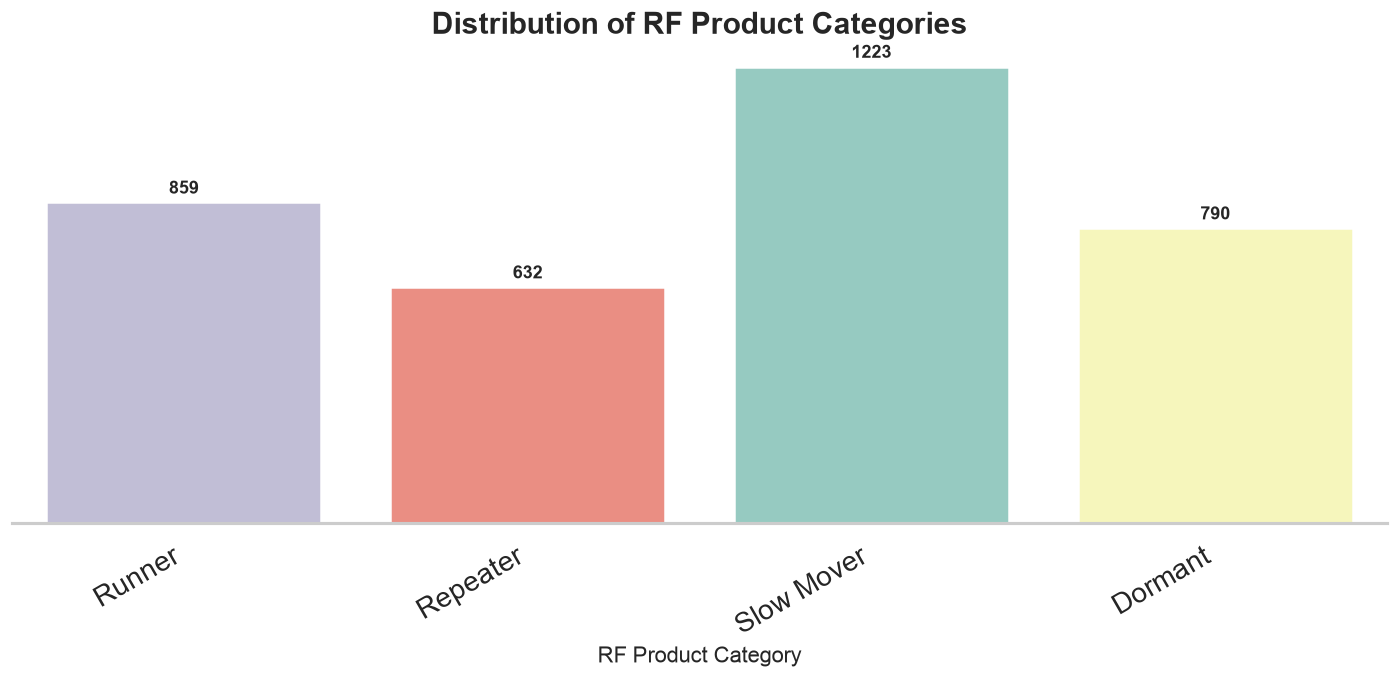

In [105]:
plt.figure(figsize=(12,6))

rf_order = [
  
    "Runner",
    "Repeater",
    "Slow Mover",
    "Dormant"
    
]

ax = sns.countplot(
    data=product_summary,
    x="RF_Category",
    hue="RF_Category",
    order=rf_order,
    palette="Set3",
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        fontsize=11,
        fontweight="bold",
        padding=3
    )

# Remove y-axis
sns.despine(left=True)
ax.yaxis.set_visible(False)

plt.title(
    "Distribution of RF Product Categories",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("RF Product Category", fontsize=13)
plt.ylabel("")

# Rotate labels for better readability
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### 4.9 Key Observations

### Observation

- The RF analysis classified the product portfolio into four behavioural categories: **Runner**, **Repeater**, **Slow Mover**, and **Dormant**, based on product recency and ordering frequency.

- **Slow Movers** represent the largest segment, comprising **1,123 products**. These products exhibit declining or inconsistent ordering behaviour and should be periodically reviewed to optimize inventory investment.

- **Runner** products account for **737 products**, indicating a substantial group of products with high ordering frequency and recent demand. These products should receive the highest inventory priority to minimize stock-out risk.

- **Dormant** products constitute **704 products**, representing items with prolonged inactivity and low ordering frequency. These products should be evaluated for inventory rationalization, make-to-order strategies, or possible discontinuation.

- **Repeater** products include **613 products**, reflecting products with stable and recurring demand that require regular replenishment and standard inventory control.

- Overall, approximately **56%** of the product portfolio (**1,827 products**) belongs to the **Slow Mover** and **Dormant** categories, highlighting a significant opportunity to optimize inventory carrying costs.

- Conversely, **1,350 products** (**Runner** and **Repeater**) demonstrate active ordering behaviour and should remain the primary focus of inventory planning, replenishment, and service-level management.

- The RF classification provides a behavioural view of the product portfolio, which will be integrated with the ABC analysis to develop differentiated inventory policies and calculate appropriate Reorder Levels (ROL).

| Segment | Recency | Frequency | No. of Products | Interpretation | Recommended Inventory Policy |
|----------|----------|-----------|----------------:|----------------|------------------------------|
| **Runner** | High | High | **737** | Frequently ordered and recently active products representing the highest inventory priority. | Maintain the highest service level (95-99%), continuous monitoring, frequent replenishment, and higher safety stock. |
| **Repeater** | Medium | Medium to High | **613** | Products with stable and recurring demand requiring consistent inventory availability. | Maintain standard replenishment cycles with moderate safety stock and periodic demand review. |
| **Slow Mover** | Medium to Low | Low to Medium | **1,123** | Products exhibiting declining or inconsistent demand patterns. | Reduce replenishment frequency, maintain lower inventory levels, and periodically review demand trends. |
| **Dormant** | Low | Low | **704** | Rarely ordered products with prolonged inactivity and minimal demand. | Consider make-to-order, inventory rationalization, or product phase-out to reduce carrying and storage costs. |

# 5. Product Segmentation Using ABC and RF Analysis

ABC analysis classifies products according to their contribution to total demand, while RF analysis evaluates ordering behaviour based on recency and frequency. Combining these two approaches provides a comprehensive view of product importance and ordering patterns, enabling the development of differentiated inventory management strategies.

In [106]:
# Create a combined product segment

product_summary["ABC_RF_Segment"] = (
    product_summary["ABC_Class"] +
    " - " +
    product_summary["RF_Category"]
)

product_summary[
    [
        "Item_Code",
        "ABC_Class",
        "RF_Category",
        "ABC_RF_Segment"
    ]
].head()

,Item_Code,ABC_Class,RF_Category,ABC_RF_Segment
0,011433-011.00,C,Slow Mover,C - Slow Mover
1,1028343-002,C,Dormant,C - Dormant
2,1028343-003,C,Runner,C - Runner
3,1028607,C,Dormant,C - Dormant
4,1029335,C,Dormant,C - Dormant


### 5.2 Distribution of Combined Product Segments

In [107]:
segment_summary = (
    product_summary["ABC_RF_Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Segment", "Products"]

segment_summary

,Segment,Products
0,C - Slow Mover,1060
1,C - Dormant,741
2,C - Repeater,445
3,B - Runner,354
4,C - Runner,308
5,A - Runner,197
6,B - Repeater,140
7,B - Slow Mover,131
8,A - Repeater,47
9,B - Dormant,43


### 5.3 Distribution of ABC-RF Product Segments

/var/folders/6z/z51dtvmj6pz5k2yqlwmqdmx80000gn/T/ipykernel_34869/4019264786.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


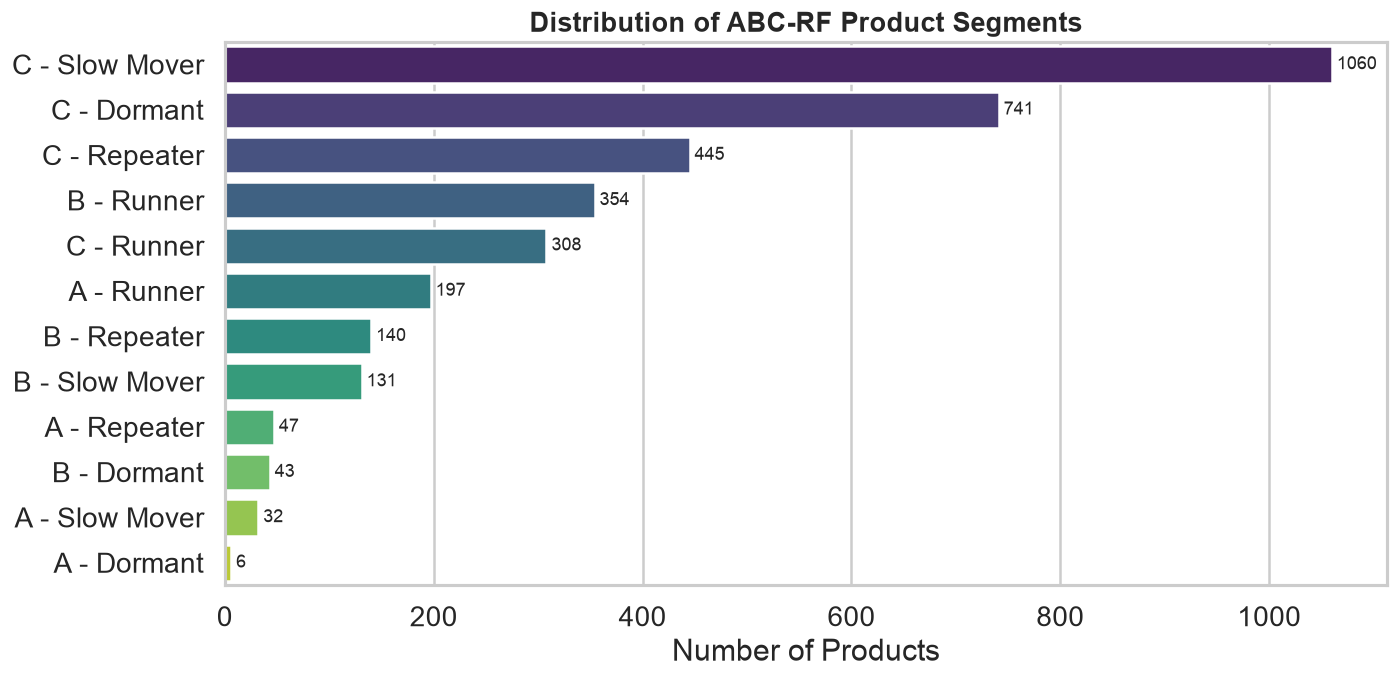

In [108]:
plt.figure(figsize=(12,6))

segment_summary = (
    product_summary["ABC_RF_Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Segment", "Products"]

ax = sns.barplot(
    data=segment_summary,
    x="Products",
    y="Segment",
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        fontsize=11,
        padding=3
    )

plt.title(
    "Distribution of ABC-RF Product Segments",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Products")
plt.ylabel("")

plt.tight_layout()
plt.show()

### 5.4 Product Segmentation Matrix

In [109]:
segment_matrix = pd.crosstab(
    product_summary["ABC_Class"],
    product_summary["RF_Category"]
)

segment_matrix

RF_Category,Dormant,Repeater,Runner,Slow Mover
ABC_Class,,,,
A,6,47,197,32
B,43,140,354,131
C,741,445,308,1060


### 5.5 Heatmap of Product Segmentation

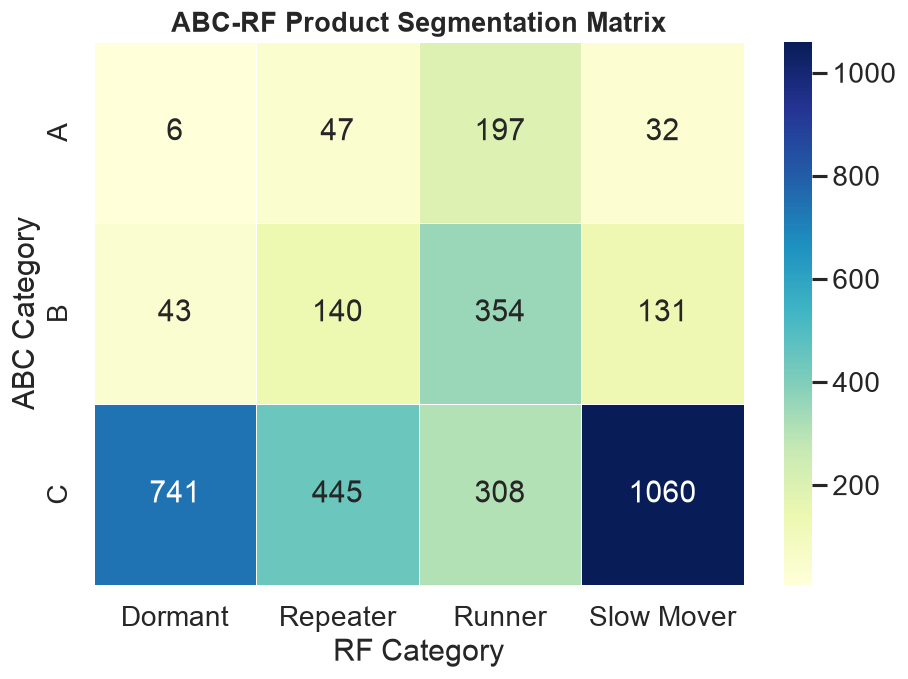

In [110]:
plt.figure(figsize=(8,6))

sns.heatmap(
    segment_matrix,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "ABC-RF Product Segmentation Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("RF Category")
plt.ylabel("ABC Category")

plt.tight_layout()
plt.show()

| ABC | RF Segment | No. of Products | Interpretation | Recommended Inventory Policy |
|-----|------------|----------------:|----------------|------------------------------|
| **A** | Runner | **223** | High-value products with high ordering frequency and recent demand. These are the most critical inventory items. | Maintain the highest service level (98-99%), continuous monitoring, frequent replenishment, and higher safety stock. |
| **A** | Repeater | **85** | High-value products with regular and stable demand. | Maintain standard replenishment cycles with moderate safety stock and periodic demand reviews. |
| **A** | Slow Mover | **89** | High-value products with declining or inconsistent ordering behaviour. | Review demand frequently, maintain minimum inventory, and reduce replenishment frequency where appropriate. |
| **A** | Dormant | **11** | High-value products with prolonged inactivity. | Investigate product lifecycle and retain inventory only if business critical or contractually required. |
| **B** | Runner | **182** | Medium-value products with consistently high ordering activity. | Maintain high service levels with scheduled replenishment and periodic monitoring. |
| **B** | Repeater | **167** | Medium-value products with stable and recurring demand. | Maintain normal inventory levels with routine replenishment and moderate safety stock. |
| **B** | Slow Mover | **192** | Medium-value products showing declining demand. | Reduce replenishment frequency and periodically review inventory levels. |
| **B** | Dormant | **77** | Medium-value products with prolonged inactivity. | Maintain limited inventory and review periodically for possible rationalization. |
| **C** | Runner | **332** | Low-value products with high ordering frequency. Although individual demand is low, these products are ordered consistently. | Maintain lean inventory with efficient replenishment to support continuous demand. |
| **C** | Repeater | **361** | Low-value products with stable but moderate ordering behaviour. | Maintain low-to-moderate inventory levels with periodic replenishment. |
| **C** | Slow Mover | **842** | Low-value products with declining or inconsistent demand. This is the largest active inventory segment. | Minimize inventory investment, replenish only when necessary, and review periodically for optimization. |
| **C** | Dormant | **616** | Low-value products with prolonged inactivity and minimal demand. | Consider make-to-order, product phase-out, or inventory rationalization to reduce warehouse space and carrying costs. |

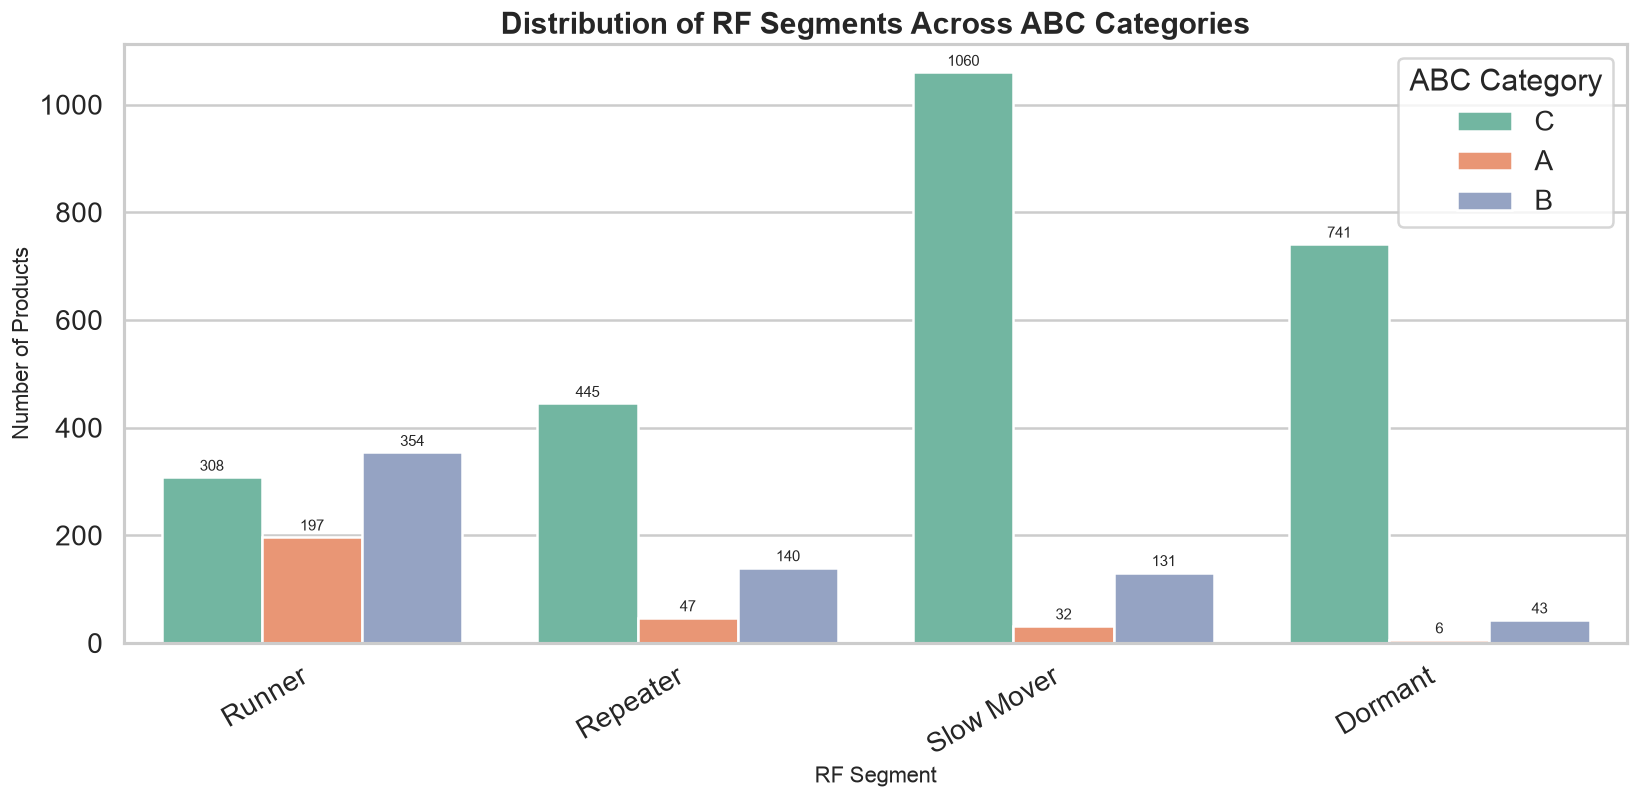

In [111]:
plt.figure(figsize=(14,7))

ax = sns.countplot(
    data=product_summary,
    x="RF_Category",
    hue="ABC_Class",
    order=[
 
        "Runner",
        "Repeater",
        "Slow Mover",
        "Dormant"
    ],
    palette="Set2"
)

# Add labels to each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        fontsize=9,
        padding=2
    )

plt.title(
    "Distribution of RF Segments Across ABC Categories",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("RF Segment", fontsize=13)
plt.ylabel("Number of Products", fontsize=13)

plt.xticks(rotation=30, ha="right")
plt.legend(title="ABC Category")

plt.tight_layout()
plt.show()

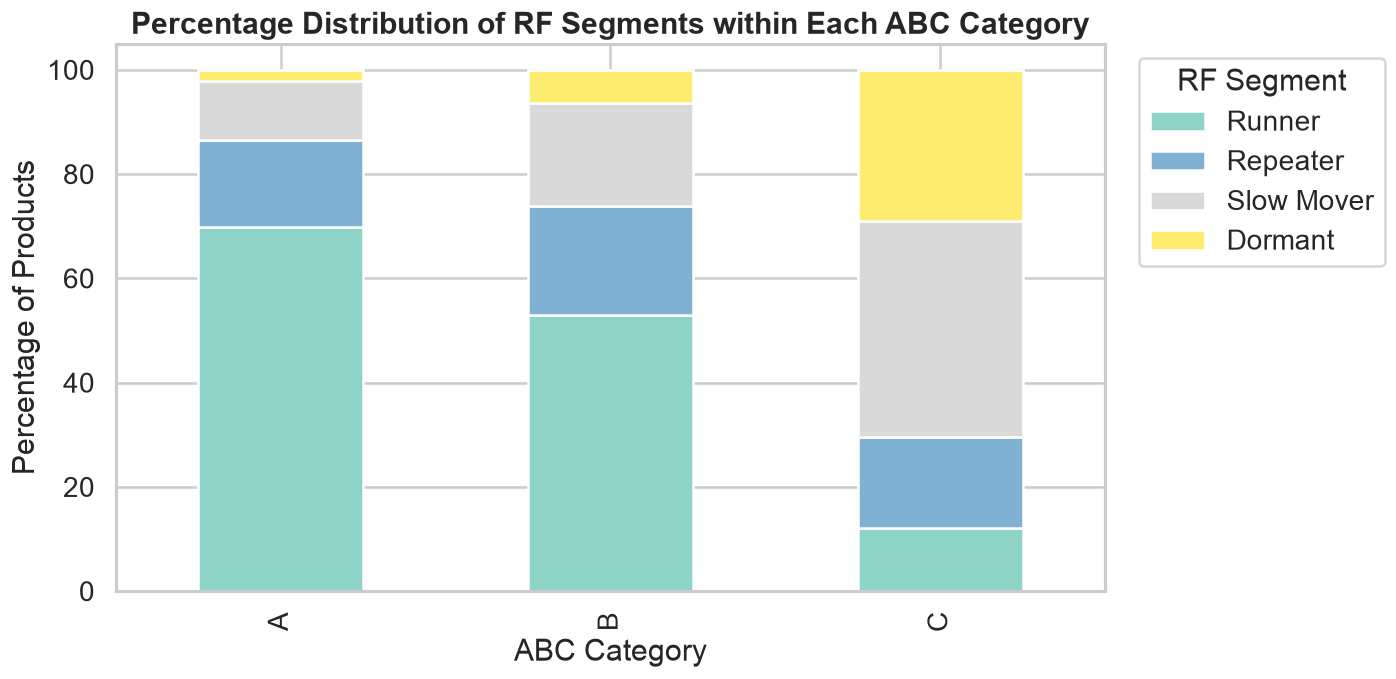

In [112]:
segment_pct = (
    pd.crosstab(
        product_summary["ABC_Class"],
        product_summary["RF_Category"],
        normalize="index"
    ) * 100
)

segment_pct = segment_pct[
    [

        "Runner",
        "Repeater",
   
        "Slow Mover",
        "Dormant"
    ]
]

segment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="Set3"
)

plt.title(
    "Percentage Distribution of RF Segments within Each ABC Category",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("ABC Category")
plt.ylabel("Percentage of Products")
plt.legend(
    title="RF Segment",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

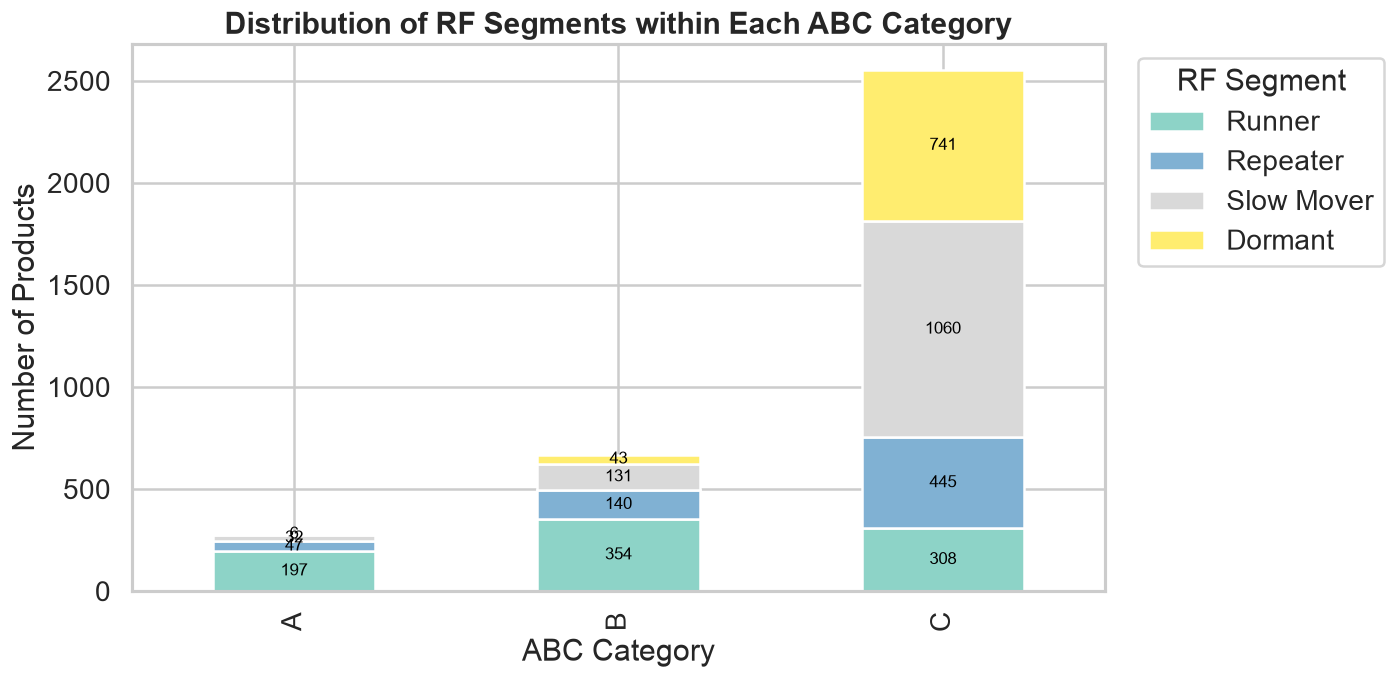

In [113]:
# Create a contingency table with actual product counts
segment_count = pd.crosstab(
    product_summary["ABC_Class"],
    product_summary["RF_Category"]
)

# Arrange columns in the desired order
segment_count = segment_count[
    [
        "Runner",
        "Repeater",
        "Slow Mover",
        "Dormant"
    ]
]

# Plot stacked bar chart
ax = segment_count.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="Set3"
)

# Add value labels inside each stack
for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",
        fontsize=10,
        color="black"
    )

plt.title(
    "Distribution of RF Segments within Each ABC Category",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("ABC Category")
plt.ylabel("Number of Products")

plt.legend(
    title="RF Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [114]:
# Higher score = More recent product
product_summary["R_Score"] = pd.qcut(
    product_summary["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Higher score = More frequently ordered product
product_summary["F_Score"] = pd.qcut(
    product_summary["Total_Orders"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [115]:
def classify_rf(row):
    r = row["R_Score"]
    f = row["F_Score"]

    if r >= 4 and f >= 4:
        return "Runner"

    elif r >= 3 and f >= 3:
        return "Repeater"

    elif r <= 2 and f <= 2:
        return "Dormant"

    else:
        return "Slow Mover"
        
product_summary["RF_Category"] = product_summary.apply(
    classify_rf,
    axis=1
)



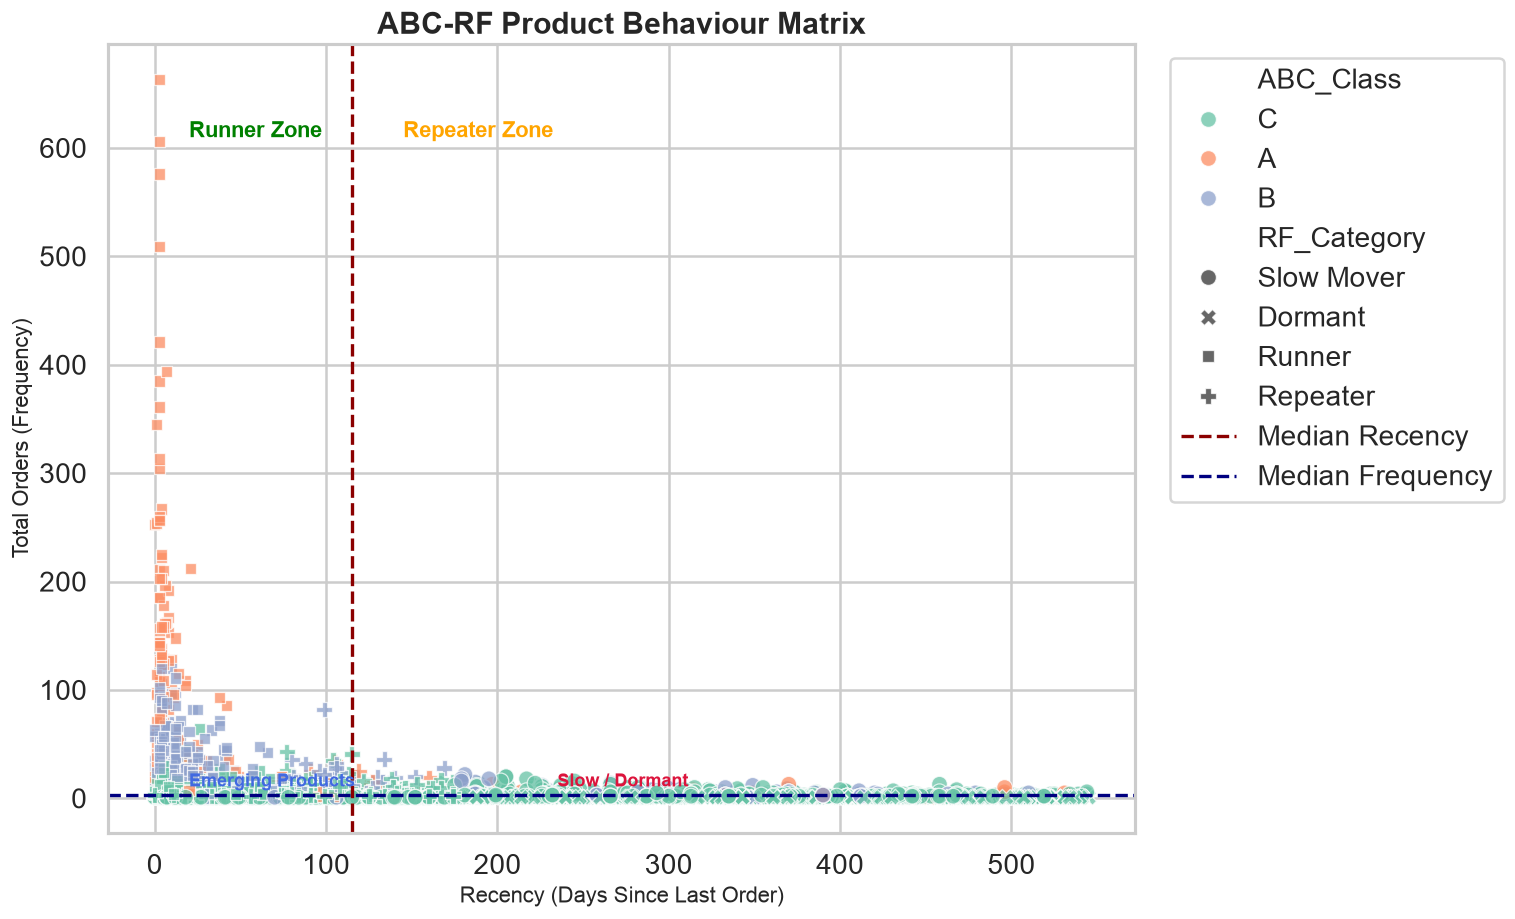

In [116]:
plt.figure(figsize=(13,8))

ax = sns.scatterplot(
    data=product_summary,
    x="Recency",
    y="Total_Orders",
    hue="ABC_Class",
    style="RF_Category",
    palette="Set2",
    s=90,
    alpha=0.75
)

# Median Recency
plt.axvline(
    product_summary["Recency"].median(),
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Median Recency"
)

# Median Frequency
plt.axhline(
    product_summary["Total_Orders"].median(),
    color="navy",
    linestyle="--",
    linewidth=2,
    label="Median Frequency"
)

# Quadrant Labels
plt.text(
    20,
    product_summary["Total_Orders"].max()*0.92,
    "Runner Zone",
    fontsize=13,
    color="green",
    weight="bold"
)

plt.text(
    product_summary["Recency"].median()+30,
    product_summary["Total_Orders"].max()*0.92,
    "Repeater Zone",
    fontsize=13,
    color="orange",
    weight="bold"
)

plt.text(
    20,
    product_summary["Total_Orders"].median()+8,
    "Emerging Products",
    fontsize=11,
    color="royalblue",
    weight="bold"
)

plt.text(
    product_summary["Recency"].median()+120,
    product_summary["Total_Orders"].median()+8,
    "Slow / Dormant",
    fontsize=11,
    color="crimson",
    weight="bold"
)

plt.title(
    "ABC-RF Product Behaviour Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Recency (Days Since Last Order)",
    fontsize=13
)

plt.ylabel(
    "Total Orders (Frequency)",
    fontsize=13
)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [117]:


#see column names of the product_summary dataframe

print(product_summary.columns)

Index(['Item_Code', 'Item_Name', 'Total_Orders', 'Total_Qty', 'Avg_Order_Qty',
       'Customers', 'First_Order', 'Last_Order', 'Order_Span_Days',
       'Orders_per_Month', 'Avg_Weekly_Qty', 'Std_Weekly_Qty', 'CV', 'Recency',
       'ABC_Class', 'R_Score', 'F_Score', 'RF_Score', 'RF_Category',
       'ABC_RF_Segment'],
      dtype='object')


In [118]:
columns_to_keep = ['Item_Code', 'Item_Name', 'Total_Orders', 'Total_Qty',
       'Customers', 'First_Order', 'Last_Order', 'Order_Span_Days', 'CV', 'Recency',
       'ABC_Class', 'R_Score', 'F_Score', 'RF_Score', 'RF_Category',
       'ABC_RF_Segment']


product_summary.to_excel(
    f"sheet_{sheet_name}_final_product_summary.xlsx",
    index=False,
    columns=columns_to_keep
)



| ABC | RF Segment | Inventory Priority | Service Level | Review Policy | Safety Stock | Replenishment Strategy |
|-----|------------|-------------------|---------------|---------------|--------------|------------------------|
| A | Runner | Highest | 99% | Continuous | Very High | Immediate replenishment |
| A | Repeater | High | 98% | Weekly | High | Regular replenishment |
| A | Slow Mover | Medium | 95% | Monthly | Medium | Replenish only when required |
| A | Dormant | Low | 90% | Quarterly | Low | Make-to-order or management approval |
| B | Runner | High | 97% | Weekly | High | Scheduled replenishment |
| B | Repeater | Medium | 95% | Monthly | Medium | Standard replenishment |
| B | Slow Mover | Medium | 92% | Monthly | Low | Conservative replenishment |
| B | Dormant | Low | 88% | Quarterly | Very Low | Purchase only when demand arises |
| C | Runner | Medium | 95% | Monthly | Medium | Lean inventory with frequent review |
| C | Repeater | Low | 92% | Monthly | Low | Replenish based on consumption |
| C | Slow Mover | Very Low | 88% | Quarterly | Very Low | Minimize inventory |
| C | Dormant | Lowest | 80% | On Demand | None | Make-to-order or discontinue |

In [119]:
validation = (
    df.groupby("Item_Code")
      .agg(
          Input_Orders=("OA_No", "count"),
          Input_Qty=("Order_Qty", "sum"),
          Input_Customers=("Party_Code", "nunique")
      )
      .reset_index()
)

validation = validation.merge(
    product_summary[
        [
            "Item_Code",
            "Total_Orders",
            "Total_Qty",
            "Customers"
        ]
    ],
    on="Item_Code"
)

validation["Orders_Match"] = (
    validation["Input_Orders"] == validation["Total_Orders"]
)

validation["Qty_Match"] = (
    validation["Input_Qty"] == validation["Total_Qty"]
)

validation["Customer_Match"] = (
    validation["Input_Customers"] == validation["Customers"]
)

validation.head()

,Item_Code,Input_Orders,Input_Qty,Input_Customers,Total_Orders,Total_Qty,Customers,Orders_Match,Qty_Match,Customer_Match
0,011433-011.00,1,10.0,1,1,10.0,1,True,True,True
1,1028343-002,1,1.0,1,1,1.0,1,True,True,True
2,1028343-003,7,10.0,1,7,10.0,1,True,True,True
3,1028607,1,1.0,1,1,1.0,1,True,True,True
4,1029335,1,1.0,1,1,1.0,1,True,True,True


In [120]:
# ==========================================================
# Cross Validation: Input Data vs Output Data
# ==========================================================

# Calculate expected values directly from the raw input
validation = (
    df.groupby("Item_Code")
      .agg(
          Input_Orders=("OA_No", "count"),
          Input_Total_Qty=("Order_Qty", "sum"),
          Input_Avg_Order_Qty=("Order_Qty", "mean"),
          Input_Customers=("Party_Code", "nunique"),
          Input_First_Order=("OriginalOA_Date", "min"),
          Input_Last_Order=("OriginalOA_Date", "max")
      )
      .reset_index()
)

# Merge with the calculated output
validation = validation.merge(
    product_summary[
        [
            "Item_Code",
            "Total_Orders",
            "Total_Qty",
            "Avg_Order_Qty",
            "Customers",
            "First_Order",
            "Last_Order"
        ]
    ],
    on="Item_Code",
    how="left"
)

# Compare every field
validation["Orders_Match"] = validation["Input_Orders"] == validation["Total_Orders"]
validation["Qty_Match"] = validation["Input_Total_Qty"] == validation["Total_Qty"]
validation["Avg_Qty_Match"] = validation["Input_Avg_Order_Qty"] == validation["Avg_Order_Qty"]
validation["Customers_Match"] = validation["Input_Customers"] == validation["Customers"]
validation["First_Order_Match"] = validation["Input_First_Order"] == validation["First_Order"]
validation["Last_Order_Match"] = validation["Input_Last_Order"] == validation["Last_Order"]

# Keep only mismatches
mismatch = validation[
    ~(
        validation["Orders_Match"] &
        validation["Qty_Match"] &
        validation["Avg_Qty_Match"] &
        validation["Customers_Match"] &
        validation["First_Order_Match"] &
        validation["Last_Order_Match"]
    )
]

# Display results
if mismatch.empty:
    print("Validation Successful! All products match the input data.")
else:
    print(f"Found {len(mismatch)} mismatched products.")
    display(mismatch)

Validation Successful! All products match the input data.
